# Emotion CAA Position-Mode Steering Comparison

This notebook compares three generation conditions for pooled emotion CAA vectors at layer 13:

1. `none`: no activation steering.
2. `last_token`: add the steering delta to `hidden[:, -1:, :]` on every forward pass during `generate()`. This steers the prompt prefill final token and every decode step.
3. `completion_tokens`: skip prompt prefill and only add the delta when `hidden.shape[1] == 1`, which is the usual cached-decoding path where exactly one new token is processed.

The experiment uses the original pooled CAA vector $c_e$ for each emotion, re-normalizes it to unit norm before multiplying by $\alpha$, runs a deterministic alpha sweep, saves generation rows incrementally to JSONL and CSV, builds an OpenAI Batch API judge file, and summarizes best alpha, safe alpha ranges, negative-alpha behavior, and last-token vs completion-token tradeoffs.

In [16]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml
from IPython.display import display
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

warnings.filterwarnings('ignore', category=UserWarning)

REPO_ROOT = Path('../..').resolve()
ACT_DIR = REPO_ROOT / 'activation' / 'emotion_rewrites'
CAA_PATH = ACT_DIR / 'caa_emotion_directions.npz'
CAA_INFO = ACT_DIR / 'caa_emotion_directions_info.json'
REWRITE_JSONL = REPO_ROOT / 'dataset' / 'emotion_rewrites' / 'emotion_rewrites.jsonl'
OUT_DIR = REPO_ROOT / 'analysis' / 'caa' / 'position_mode_steering'
OUT_DIR.mkdir(parents=True, exist_ok=True)

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

from emotionengine.steering_utils import (
    append_jsonl_csv_row as append_generation_row,
    chunk_list,
    extract_message_content,
    flush_device_cache as _flush_device_cache,
    format_alpha_list,
    generate_rewrite,
    generate_rewrite_batch,
    generation_key,
    interpret_negative_alpha_row as interpret_negative_alpha,
    load_generation_cache,
    load_generation_df,
    unit_np,
)

GENERATIONS_JSONL = OUT_DIR / 'position_mode_generations.jsonl'
GENERATIONS_CSV = OUT_DIR / 'position_mode_generations.csv'
JUDGE_REQUESTS_FILE = OUT_DIR / 'position_mode_judge_requests.jsonl'
JUDGE_REQUEST_META_FILE = OUT_DIR / 'position_mode_judge_request_meta.jsonl'
JUDGE_RESULTS_FILE = OUT_DIR / 'position_mode_judge_results.jsonl'
PARSED_JUDGE_JSONL = OUT_DIR / 'position_mode_judge_parsed.jsonl'
PARSED_JUDGE_CSV = OUT_DIR / 'position_mode_judge_parsed.csv'
SUMMARY_CSV = OUT_DIR / 'position_mode_summary.csv'
BEST_ALPHA_CSV = OUT_DIR / 'position_mode_best_alpha.csv'
SAFE_RANGE_CSV = OUT_DIR / 'position_mode_safe_ranges.csv'
NEGATIVE_ALPHA_CSV = OUT_DIR / 'position_mode_negative_alpha_summary.csv'
MODE_COMPARISON_CSV = OUT_DIR / 'position_mode_mode_comparison.csv'

PRIMARY_LAYER = 13
MAX_EXAMPLES = 20
MAX_NEW_TOKENS = 100
DO_SAMPLE = False
SEED = 42
ALPHA_SWEEP = [-8, -5, -3, -2, -1, 0, 1, 2, 3, 5, 8]
STEERING_MODES = ['none', 'last_token', 'completion_tokens']
BATCH_SIZE = 4
CACHE_FLUSH_EVERY = 16
JUDGE_MODEL = 'gpt-4.1-mini'
SUBMIT_EVAL_BATCH = True
SAFE_THRESHOLDS = {
    'meaning_preservation': 8.0,
    'fluency_naturalness': 8.0,
    'oversteering_artifact': 3.0,
}

OPPOSITE_EMOTION = {
    'joy': 'sadness',
    'sadness': 'joy',
    'trust': 'disgust',
    'disgust': 'trust',
    'fear': 'anger',
    'anger': 'fear',
    'surprise': 'anticipation',
    'anticipation': 'surprise',
}

rng = np.random.default_rng(SEED)
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 150})

print(f'Repo root      : {REPO_ROOT}')
print(f'Output dir     : {OUT_DIR}')
print(f'Primary layer  : {PRIMARY_LAYER}')
print(f'MAX_EXAMPLES   : {MAX_EXAMPLES}')
print(f'Alpha sweep    : {ALPHA_SWEEP}')
print(f'Steering modes : {STEERING_MODES}')
print(f'Batch size     : {BATCH_SIZE}')

Repo root      : /home/maplesugano/proj/EmotionEngine_v2
Output dir     : /home/maplesugano/proj/EmotionEngine_v2/analysis/caa/position_mode_steering
Primary layer  : 13
MAX_EXAMPLES   : 20
Alpha sweep    : [-8, -5, -3, -2, -1, 0, 1, 2, 3, 5, 8]
Steering modes : ['none', 'last_token', 'completion_tokens']
Batch size     : 4


In [2]:
with open(CAA_INFO, encoding='utf-8') as f:
    caa_meta = json.load(f)

EMOTION_ORDER = list(caa_meta['emotion_order'])
LAYER_INDICES = list(caa_meta['layer_indices'])
LI = LAYER_INDICES.index(PRIMARY_LAYER)

caa_data = np.load(CAA_PATH)
caa_pooled = np.asarray(caa_data['caa_pooled'], dtype=np.float32)
C = np.stack([unit_np(vec) for vec in caa_pooled[:, LI, :]], axis=0)
D = int(C.shape[-1])
EMOTION_TO_INDEX = {emo: i for i, emo in enumerate(EMOTION_ORDER)}

records_raw: list[dict[str, Any]] = []
with open(REWRITE_JSONL, encoding='utf-8') as f:
    for line in f:
        records_raw.append(json.loads(line))

medium_test_by_source: dict[str, dict[str, Any]] = {}
for rec in records_raw:
    sid = rec.get('source_id', '')
    if not sid or sid in medium_test_by_source:
        continue
    if rec.get('source_split') == 'test' and rec.get('intensity_level') == 'medium':
        medium_test_by_source[sid] = rec

if len(medium_test_by_source) < MAX_EXAMPLES:
    fallback_by_source: dict[str, dict[str, Any]] = {}
    for rec in records_raw:
        sid = rec.get('source_id', '')
        if not sid or sid in fallback_by_source:
            continue
        if rec.get('source_split') == 'test':
            fallback_by_source[sid] = rec
    source_records = list(fallback_by_source.values())
else:
    source_records = list(medium_test_by_source.values())

source_records = sorted(source_records, key=lambda rec: rec['source_id'])
sample_size = min(MAX_EXAMPLES, len(source_records))
sample_idx = rng.choice(len(source_records), size=sample_size, replace=False)
held_out = [source_records[i] for i in sorted(sample_idx)]

preview_df = pd.DataFrame([{
    'source_id': rec['source_id'],
    'source_split': rec.get('source_split'),
    'intensity_level': rec.get('intensity_level'),
    'base_text': rec['base_text'][:120],
} for rec in held_out])

print(f'Loaded pooled CAA vectors: {C.shape} (emotion, hidden)')
print(f'Layer indices            : {LAYER_INDICES} -> LI={LI}')
print(f'Hidden size              : {D}')
print(f'Held-out base texts      : {len(held_out)}')
display(preview_df.head())

Loaded pooled CAA vectors: (8, 4096) (emotion, hidden)
Layer indices            : [8, 10, 13, 16, 19, 22] -> LI=2
Hidden size              : 4096
Held-out base texts      : 20


,source_id,source_split,intensity_level,base_text
0,dd_test_175_0,test,medium,Can I help you ? Yes . I want to buy a pair o...
1,dd_test_186_0,test,medium,I have to check out now . My name is Ruth Cars...
2,dd_test_218_0,test,medium,Thank God ! I am finished writing that service...
3,dd_test_279_0,test,medium,"Excuse me , sir.Is there a barber near here ? ..."
4,dd_test_513_0,test,medium,I am sorry to have kept all of you waiting . I...


In [3]:
from emotionengine.text_utils import extract_rewritten_text
from scripts.submit_openai_batch import submit_batch_file, summarize_jsonl

with open(REPO_ROOT / 'model.yaml', encoding='utf-8') as f:
    model_cfg = yaml.safe_load(f)

MODEL_NAME = model_cfg['name']
DTYPE_MAP = {
    'bfloat16': torch.bfloat16,
    'float16': torch.float16,
    'float32': torch.float32,
}
MODEL_DTYPE = DTYPE_MAP.get(model_cfg.get('dtype', 'bfloat16'), torch.bfloat16)
ATTN_IMPL = model_cfg.get('attn_implementation', 'sdpa')
USE_4BIT = bool(model_cfg.get('load_in_4bit', False))

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.padding_side = 'left'
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

bnb_cfg = None
if USE_4BIT:
    bnb_cfg = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type='nf4',
    )

print(f'Loading model: {MODEL_NAME}')
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=MODEL_DTYPE,
    attn_implementation=ATTN_IMPL,
    device_map='auto',
    low_cpu_mem_usage=True,
    quantization_config=bnb_cfg,
 )
model.eval()
MODEL_INPUT_DEVICE = next(model.parameters()).device

print(f'Model dtype     : {MODEL_DTYPE}')
print(f'Attention impl  : {ATTN_IMPL}')
print(f'4-bit quantized : {USE_4BIT}')
print(f'Input device    : {MODEL_INPUT_DEVICE}')

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading model: meta-llama/Llama-3.1-8B-Instruct


Loading weights: 100%|██████████| 291/291 [00:02<00:00, 138.36it/s]


Model dtype     : torch.bfloat16
Attention impl  : sdpa
4-bit quantized : False
Input device    : cuda:0


## Steering Semantics

The hook below is explicit about prompt prefill versus decode steps:

- `last_token`: always add $\Delta = \alpha \hat{c}_e$ to the final hidden position at the target layer. This includes the prompt prefill pass.
- `completion_tokens`: add the same delta only when `hidden.shape[1] == 1`. With KV cache enabled, prompt prefill has `seq_len > 1` and each decode step has `seq_len == 1`, so the prompt stays untouched and only completion token positions are steered.
- If generation ever stops using cached single-token decoding, `completion_tokens` stays conservative and skips those multi-token forwards. Hook call counters make that visible.

In [4]:
PROMPT_TEMPLATE = (
    "Please rewrite this so it aligns with my feelings more: base:  {base_text}"
)

GENERATION_FIELDNAMES = [
    'source_id',
    'source_split',
    'intensity_level',
    'base_text',
    'target_emotion',
    'opposite_emotion',
    'alpha',
    'steering_mode',
    'layer',
    'generated_text',
    'hook_calls',
    'hook_prefill_calls',
    'hook_decode_calls',
    'hook_applied_calls',
]

GENERATION_KWARGS = {
    'model': model,
    'tokenizer': tokenizer,
    'model_input_device': MODEL_INPUT_DEVICE,
    'caa_vectors': C,
    'emotion_to_index': EMOTION_TO_INDEX,
    'prompt_template': PROMPT_TEMPLATE,
    'layer_idx': PRIMARY_LAYER,
    'max_new_tokens': MAX_NEW_TOKENS,
    'do_sample': DO_SAMPLE,
    'text_postprocessor': extract_rewritten_text,
}

In [5]:
smoke_record = held_out[0]
smoke_emotion = EMOTION_ORDER[0]
smoke_alpha = 3

smoke_rows = []
for mode in STEERING_MODES:
    result = generate_rewrite(
        base_text=smoke_record['base_text'],
        target_emotion=smoke_emotion,
        alpha=smoke_alpha,
        steering_mode=mode,
        **GENERATION_KWARGS,
    )
    smoke_rows.append({
        'mode': mode,
        'hook_calls': result['hook_calls'],
        'hook_prefill_calls': result['hook_prefill_calls'],
        'hook_decode_calls': result['hook_decode_calls'],
        'hook_applied_calls': result['hook_applied_calls'],
        'generated_text': result['generated_text'],
    })

smoke_df = pd.DataFrame(smoke_rows)
display(smoke_df[['mode', 'hook_calls', 'hook_prefill_calls', 'hook_decode_calls', 'hook_applied_calls']])
display(smoke_df[['mode', 'generated_text']])

,mode,hook_calls,hook_prefill_calls,hook_decode_calls,hook_applied_calls
0,none,0,0,0,0
1,last_token,95,1,94,95
2,completion_tokens,95,1,94,94


,mode,generated_text
0,none,"Hi, can I help you find something? Yeah, I'd ..."
1,last_token,I'd love to help you find the perfect pair of ...
2,completion_tokens,I'd love to help you find the perfect pair of ...


In [6]:
rows_by_key, none_cache = load_generation_cache(GENERATIONS_JSONL)
expected_total = len(held_out) * len(EMOTION_ORDER) * len(ALPHA_SWEEP) * len(STEERING_MODES)
pbar = tqdm(total=expected_total, desc='Position-mode sweep')
generation_counter = 0

for rec in held_out:
    source_id = rec['source_id']
    source_split = rec.get('source_split', '')
    intensity_level = rec.get('intensity_level', '')
    base_text = rec['base_text'].strip()

    if source_id not in none_cache:
        baseline_result = generate_rewrite(
            base_text=base_text,
            target_emotion=EMOTION_ORDER[0],
            alpha=0.0,
            steering_mode='none',
            **GENERATION_KWARGS,
        )
        none_cache[source_id] = baseline_result
        generation_counter += 1

    for target_emotion in EMOTION_ORDER:
        opposite_emotion = OPPOSITE_EMOTION[target_emotion]
        baseline_payload = none_cache[source_id]

        for alpha in ALPHA_SWEEP:
            none_key = generation_key(source_id, target_emotion, alpha, 'none', PRIMARY_LAYER)
            if none_key not in rows_by_key:
                row = {
                    'source_id': source_id,
                    'source_split': source_split,
                    'intensity_level': intensity_level,
                    'base_text': base_text,
                    'target_emotion': target_emotion,
                    'opposite_emotion': opposite_emotion,
                    'alpha': float(alpha),
                    'steering_mode': 'none',
                    'layer': PRIMARY_LAYER,
                    'generated_text': baseline_payload['generated_text'],
                    'hook_calls': baseline_payload['hook_calls'],
                    'hook_prefill_calls': baseline_payload['hook_prefill_calls'],
                    'hook_decode_calls': baseline_payload['hook_decode_calls'],
                    'hook_applied_calls': baseline_payload['hook_applied_calls'],
                }
                append_generation_row(GENERATIONS_JSONL, GENERATIONS_CSV, GENERATION_FIELDNAMES, row)
                rows_by_key[none_key] = row
            pbar.update(1)

for target_emotion in EMOTION_ORDER:
    opposite_emotion = OPPOSITE_EMOTION[target_emotion]
    for alpha in ALPHA_SWEEP:
        for steering_mode in ['last_token', 'completion_tokens']:
            pending_records = []
            for rec in held_out:
                key = generation_key(rec['source_id'], target_emotion, alpha, steering_mode, PRIMARY_LAYER)
                if key not in rows_by_key:
                    pending_records.append(rec)
                else:
                    pbar.update(1)

            for batch_records in chunk_list(pending_records, BATCH_SIZE):
                batch_texts = [rec['base_text'].strip() for rec in batch_records]
                batch_results = generate_rewrite_batch(
                    base_texts=batch_texts,
                    target_emotion=target_emotion,
                    alpha=float(alpha),
                    steering_mode=steering_mode,
                    **GENERATION_KWARGS,
                )

                for rec, result in zip(batch_records, batch_results):
                    source_id = rec['source_id']
                    row = {
                        'source_id': source_id,
                        'source_split': rec.get('source_split', ''),
                        'intensity_level': rec.get('intensity_level', ''),
                        'base_text': rec['base_text'].strip(),
                        'target_emotion': target_emotion,
                        'opposite_emotion': opposite_emotion,
                        'alpha': float(alpha),
                        'steering_mode': steering_mode,
                        'layer': PRIMARY_LAYER,
                        'generated_text': result['generated_text'],
                        'hook_calls': result['hook_calls'],
                        'hook_prefill_calls': result['hook_prefill_calls'],
                        'hook_decode_calls': result['hook_decode_calls'],
                        'hook_applied_calls': result['hook_applied_calls'],
                    }
                    append_generation_row(GENERATIONS_JSONL, GENERATIONS_CSV, GENERATION_FIELDNAMES, row)
                    rows_by_key[generation_key(source_id, target_emotion, alpha, steering_mode, PRIMARY_LAYER)] = row
                    generation_counter += 1
                    pbar.update(1)

                if generation_counter % CACHE_FLUSH_EVERY == 0:
                    _flush_device_cache()

_flush_device_cache()
pbar.close()

gen_df = load_generation_df(GENERATIONS_JSONL)
if gen_df is None:
    print('No generations found.')
else:
    print(f'Generation rows saved: {len(gen_df)}')
    print(f'Batch size used      : {BATCH_SIZE}')
    display(gen_df.head())

Position-mode sweep: 100%|██████████| 5280/5280 [46:11<00:00,  1.90it/s]

Generation rows saved: 5280
Batch size used      : 4


,source_id,source_split,intensity_level,base_text,target_emotion,opposite_emotion,alpha,steering_mode,layer,generated_text,hook_calls,hook_prefill_calls,hook_decode_calls,hook_applied_calls
0,dd_test_175_0,test,medium,Can I help you ? Yes . I want to buy a pair o...,joy,sadness,-8,none,13,"Can I assist you? Yes, I'd like to purchase a ...",0,0,0,0
1,dd_test_175_0,test,medium,Can I help you ? Yes . I want to buy a pair o...,joy,sadness,-8,last_token,13,"Can I help you?, to answer the question, which...",60,1,59,60
2,dd_test_175_0,test,medium,Can I help you ? Yes . I want to buy a pair o...,joy,sadness,-8,completion_tokens,13,"Can I help you?, I have several options availa...",60,1,59,59
3,dd_test_175_0,test,medium,Can I help you ? Yes . I want to buy a pair o...,joy,sadness,-5,none,13,"Can I assist you? Yes, I'd like to purchase a ...",0,0,0,0
4,dd_test_175_0,test,medium,Can I help you ? Yes . I want to buy a pair o...,joy,sadness,-5,last_token,13,Here is the rewritten text:\n\nCan I help you?...,60,1,59,60


## OpenAI Batch API Judge File

The next cell writes one Batch request per generated rewrite. The judge scores target emotion, opposite emotion, meaning preservation, fluency, oversteering, and a short rationale.

In [17]:
JUDGE_SCHEMA = {
    'type': 'object',
    'properties': {
        'target_emotion_intensity': {'type': 'number', 'minimum': 0, 'maximum': 10},
        'opposite_emotion_intensity': {'type': 'number', 'minimum': 0, 'maximum': 10},
        'meaning_preservation': {'type': 'number', 'minimum': 0, 'maximum': 10},
        'fluency_naturalness': {'type': 'number', 'minimum': 0, 'maximum': 10},
        'oversteering_artifact': {'type': 'number', 'minimum': 0, 'maximum': 10},
        'brief_rationale': {'type': 'string'},
    },
    'required': [
        'target_emotion_intensity',
        'opposite_emotion_intensity',
        'meaning_preservation',
        'fluency_naturalness',
        'oversteering_artifact',
        'brief_rationale',
    ],
    'additionalProperties': False,
}

JUDGE_SYSTEM_PROMPT = """You are evaluating emotion-steered rewrites.

Return only valid JSON following the provided schema.

Scoring guidelines:
- target_emotion_intensity: 0 means no sign of the requested target emotion, 10 means a very strong clear expression of it.
- opposite_emotion_intensity: 0 means no sign of the Plutchik opposite emotion, 10 means a very strong clear expression of the opposite emotion.
- meaning_preservation: 0 means the original meaning is lost, 10 means the meaning is preserved very well.
- fluency_naturalness: 0 means broken or unnatural text, 10 means fluent and natural.
- oversteering_artifact: 0 means no visible steering artifact, 10 means obvious artifacting, exaggerated emotional markers, or distorted text.
- brief_rationale: one short explanation covering the main tradeoff."""

JUDGE_USER_TEMPLATE = """Original base text:
{base_text}

Target emotion: {target_emotion}
Opposite emotion: {opposite_emotion}
Steering mode: {steering_mode}
Alpha: {alpha}

Generated rewrite:
{generated_text}

Please score this rewrite."""

gen_df = load_generation_df(GENERATIONS_JSONL)
if gen_df is None:
    print('No generation file found. Run the sweep cell first.')
else:
    judge_requests: list[dict[str, Any]] = []
    judge_request_meta: list[dict[str, Any]] = []
    for i, row in gen_df.reset_index(drop=True).iterrows():
        custom_id = f'position_mode_{i:07d}'
        user_content = JUDGE_USER_TEMPLATE.format(
            base_text=row['base_text'],
            target_emotion=row['target_emotion'],
            opposite_emotion=row['opposite_emotion'],
            steering_mode=row['steering_mode'],
            alpha=row['alpha'],
            generated_text=row['generated_text'],
        )
        judge_requests.append({
            'custom_id': custom_id,
            'method': 'POST',
            'url': '/v1/chat/completions',
            'body': {
                'model': JUDGE_MODEL,
                'messages': [
                    {'role': 'system', 'content': JUDGE_SYSTEM_PROMPT},
                    {'role': 'user', 'content': user_content},
                ],
                'response_format': {
                    'type': 'json_schema',
                    'json_schema': {
                        'name': 'EmotionRewriteJudgeScores',
                        'schema': JUDGE_SCHEMA,
                        'strict': True,
                    },
                },
                'temperature': 0,
            },
        })
        judge_request_meta.append({
            'custom_id': custom_id,
            'meta': {
                'source_id': row['source_id'],
                'source_split': row['source_split'],
                'intensity_level': row['intensity_level'],
                'base_text': row['base_text'],
                'target_emotion': row['target_emotion'],
                'opposite_emotion': row['opposite_emotion'],
                'alpha': float(row['alpha']),
                'steering_mode': row['steering_mode'],
                'layer': int(row['layer']),
                'generated_text': row['generated_text'],
            },
        })

    with open(JUDGE_REQUESTS_FILE, 'w', encoding='utf-8') as f:
        for req in judge_requests:
            f.write(json.dumps(req, ensure_ascii=False) + '\n')

    with open(JUDGE_REQUEST_META_FILE, 'w', encoding='utf-8') as f:
        for item in judge_request_meta:
            f.write(json.dumps(item, ensure_ascii=False) + '\n')

    summary = summarize_jsonl(JUDGE_REQUESTS_FILE)
    print(f'Wrote {len(judge_requests)} judge requests -> {JUDGE_REQUESTS_FILE}')
    print(f'Wrote request metadata sidecar -> {JUDGE_REQUEST_META_FILE}')
    print(json.dumps(summary, indent=2, ensure_ascii=False))

    if SUBMIT_EVAL_BATCH:
        submission = submit_batch_file(
            JUDGE_REQUESTS_FILE,
            description='Emotion CAA position-mode steering evaluation',
            metadata={
                'notebook': 'caa_position_mode_steering',
                'layer': str(PRIMARY_LAYER),
            },
        )
        display(submission)
    else:
        print('Submission disabled. Use scripts/submit_openai_batch.py or set SUBMIT_EVAL_BATCH=True.')

Wrote 5280 judge requests -> /home/maplesugano/proj/EmotionEngine_v2/analysis/caa/position_mode_steering/position_mode_judge_requests.jsonl
Wrote request metadata sidecar -> /home/maplesugano/proj/EmotionEngine_v2/analysis/caa/position_mode_steering/position_mode_judge_request_meta.jsonl
{
  "path": "/home/maplesugano/proj/EmotionEngine_v2/analysis/caa/position_mode_steering/position_mode_judge_requests.jsonl",
  "requests": 5280,
  "size_bytes": 12920776,
  "first_custom_id": "position_mode_0000000"
}


{'input_path': '/home/maplesugano/proj/EmotionEngine_v2/analysis/caa/position_mode_steering/position_mode_judge_requests.jsonl',
 'input_file_id': 'file-Uf3ALA4v4vYzMais3LVgzZ',
 'batch_id': 'batch_6a1ecda974d88190b2963243f817093a',
 'status': 'validating',
 'endpoint': '/v1/chat/completions',
 'completion_window': '24h',
 'metadata': {'description': 'Emotion CAA position-mode steering evaluation',
  'notebook': 'caa_position_mode_steering',
  'layer': '13'}}

In [18]:
judge_df = None
if not JUDGE_RESULTS_FILE.exists():
    print(f'{JUDGE_RESULTS_FILE} not found. Download the completed Batch output, then rerun this cell.')
elif not JUDGE_REQUESTS_FILE.exists():
    print(f'{JUDGE_REQUESTS_FILE} not found. Rebuild the request file first.')
else:
    request_meta: dict[str, dict[str, Any]] = {}
    if JUDGE_REQUEST_META_FILE.exists():
        with open(JUDGE_REQUEST_META_FILE, encoding='utf-8') as f:
            for line in f:
                obj = json.loads(line)
                custom_id = obj.get('custom_id', '')
                if custom_id:
                    request_meta[custom_id] = obj.get('meta', {})
    else:
        with open(JUDGE_REQUESTS_FILE, encoding='utf-8') as f:
            for line in f:
                obj = json.loads(line)
                request_meta[obj['custom_id']] = obj.get('_meta', {})

    parsed_rows: list[dict[str, Any]] = []
    with open(JUDGE_RESULTS_FILE, encoding='utf-8') as f:
        for line in f:
            result = json.loads(line)
            custom_id = result.get('custom_id', '')
            meta = dict(request_meta.get(custom_id, {}))

            row: dict[str, Any] = {'custom_id': custom_id, **meta}
            err = result.get('error')
            if err:
                row['judge_error'] = json.dumps(err, ensure_ascii=False)[:500]
                parsed_rows.append(row)
                continue

            content = extract_message_content(result)
            if not content:
                row['judge_error'] = 'missing_message_content'
                parsed_rows.append(row)
                continue

            try:
                scores = json.loads(content)
                row.update(scores)
            except Exception:
                row['judge_error'] = f'json_parse_failed: {content[:300]}'
            parsed_rows.append(row)

    judge_df = pd.DataFrame(parsed_rows)
    numeric_cols = [
        'alpha',
        'layer',
        'target_emotion_intensity',
        'opposite_emotion_intensity',
        'meaning_preservation',
        'fluency_naturalness',
        'oversteering_artifact',
    ]
    for col in numeric_cols:
        if col in judge_df.columns:
            judge_df[col] = pd.to_numeric(judge_df[col], errors='coerce')

    judge_df.to_json(PARSED_JUDGE_JSONL, orient='records', lines=True, force_ascii=False)
    judge_df.to_csv(PARSED_JUDGE_CSV, index=False)
    print(f'Parsed judge rows: {len(judge_df)}')
    display(judge_df.head())

Parsed judge rows: 5280


,custom_id,source_id,source_split,intensity_level,base_text,target_emotion,opposite_emotion,alpha,steering_mode,layer,generated_text,target_emotion_intensity,opposite_emotion_intensity,meaning_preservation,fluency_naturalness,oversteering_artifact,brief_rationale
0,position_mode_0000000,dd_test_175_0,test,medium,Can I help you ? Yes . I want to buy a pair o...,joy,sadness,-8.0,none,13,"Can I assist you? Yes, I'd like to purchase a ...",1,0,8,6,2,The rewrite maintains the original meaning fai...
1,position_mode_0000001,dd_test_175_0,test,medium,Can I help you ? Yes . I want to buy a pair o...,joy,sadness,-8.0,last_token,13,"Can I help you?, to answer the question, which...",0,0,0,0,9,"The rewrite is nonsensical and repetitive, los..."
2,position_mode_0000002,dd_test_175_0,test,medium,Can I help you ? Yes . I want to buy a pair o...,joy,sadness,-8.0,completion_tokens,13,"Can I help you?, I have several options availa...",1,2,2,1,7,The rewrite is largely incoherent and incomple...
3,position_mode_0000003,dd_test_175_0,test,medium,Can I help you ? Yes . I want to buy a pair o...,joy,sadness,-5.0,none,13,"Can I assist you? Yes, I'd like to purchase a ...",1,0,8,7,0,The rewrite maintains the original meaning fai...
4,position_mode_0000004,dd_test_175_0,test,medium,Can I help you ? Yes . I want to buy a pair o...,joy,sadness,-5.0,last_token,13,Here is the rewritten text:\n\nCan I help you?...,1,0,9,7,3,The rewrite preserves meaning well but shows m...


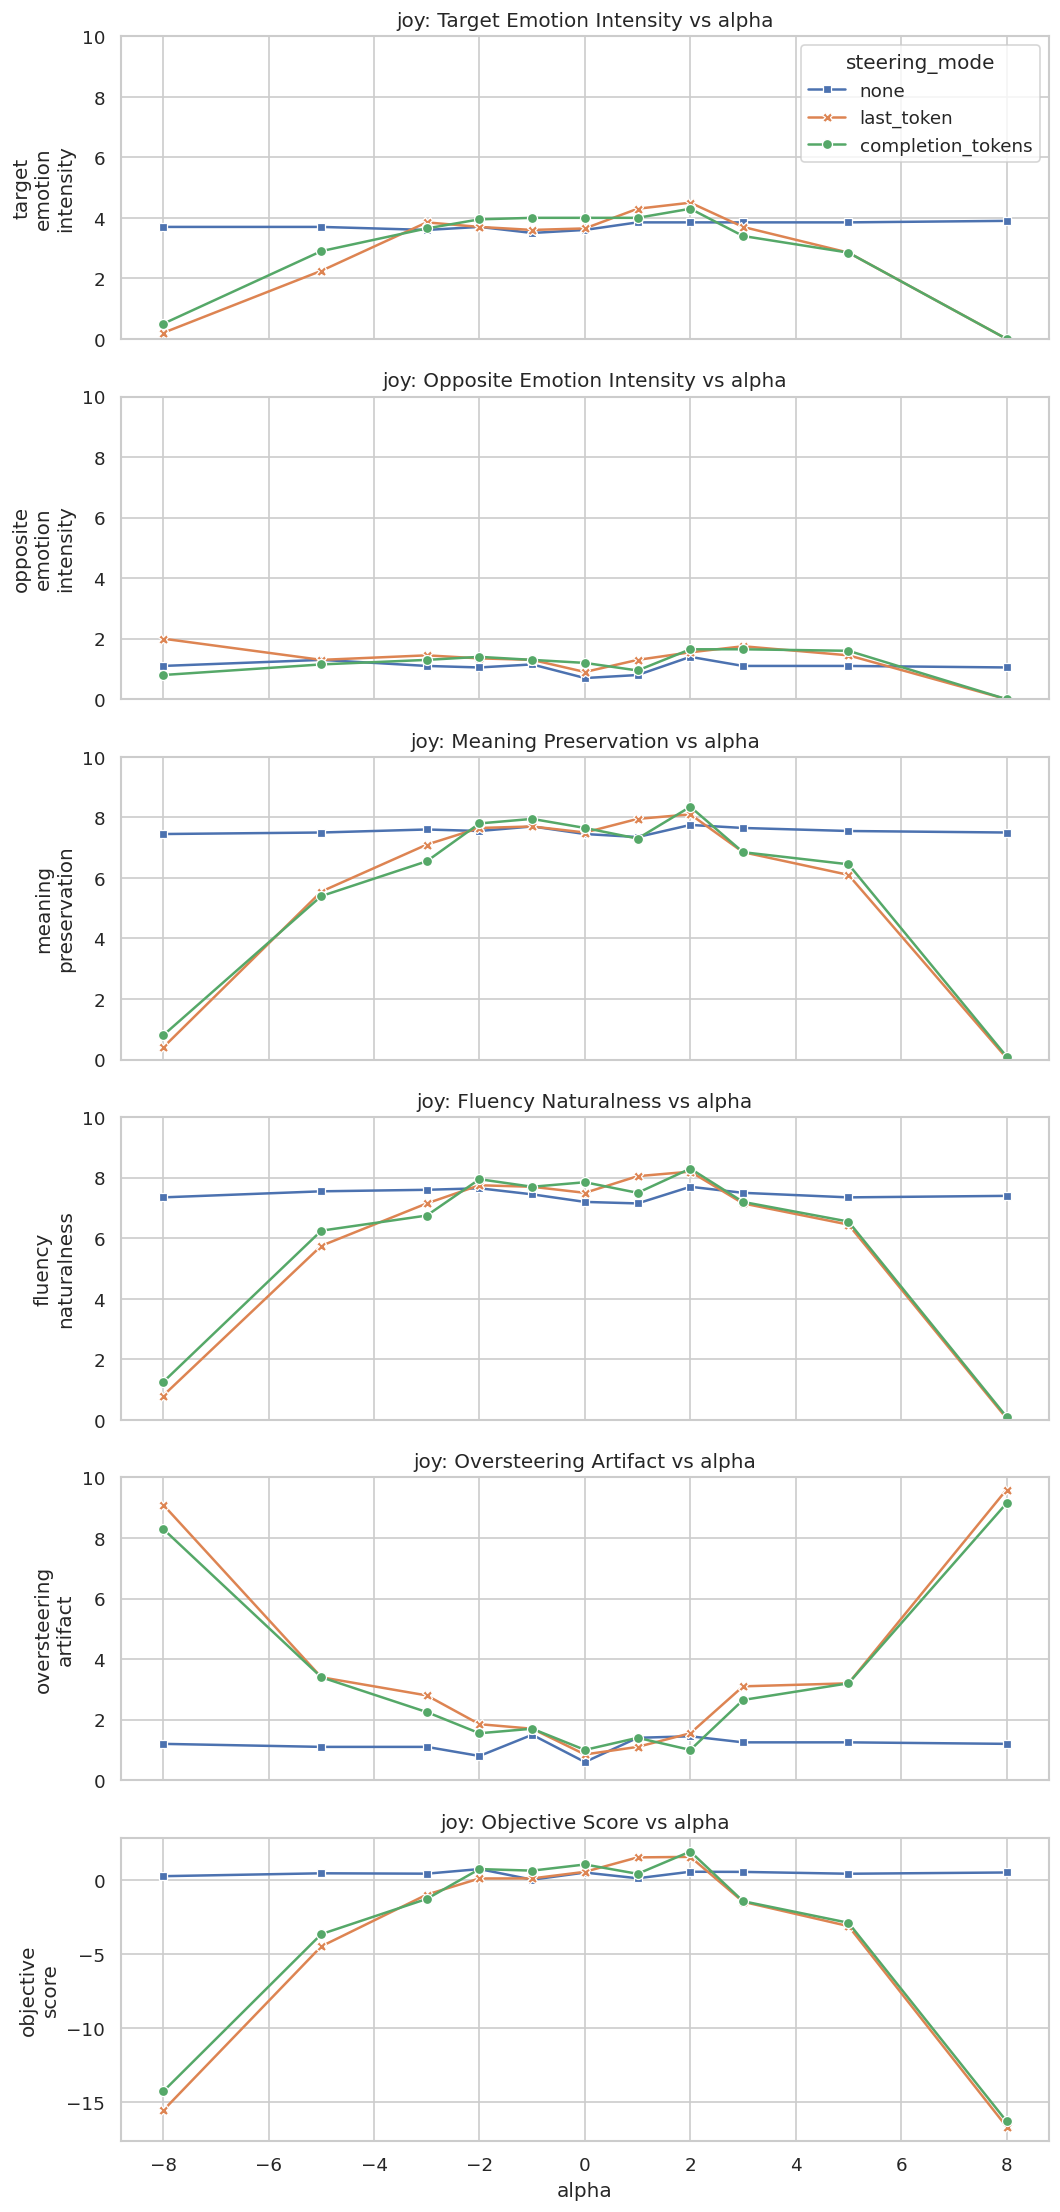

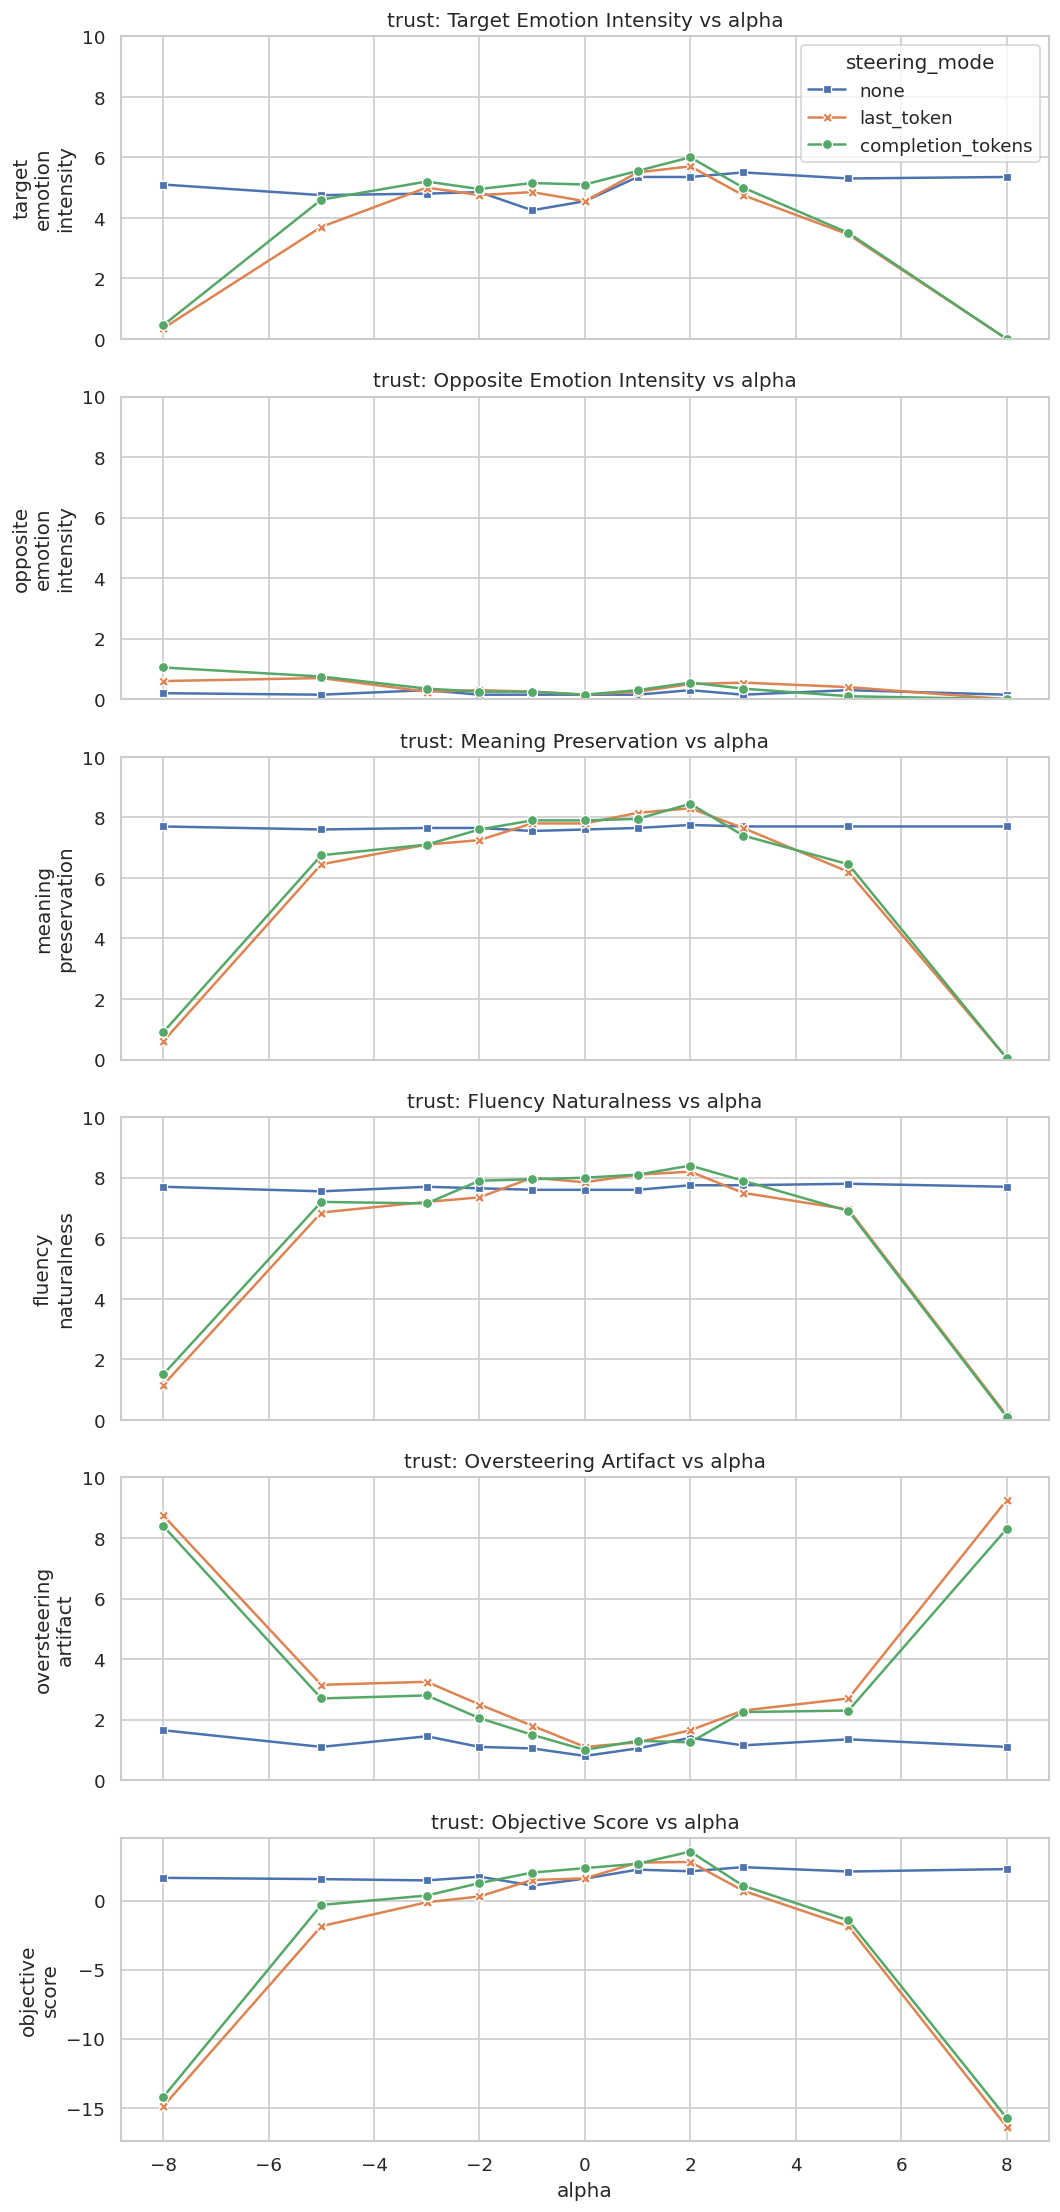

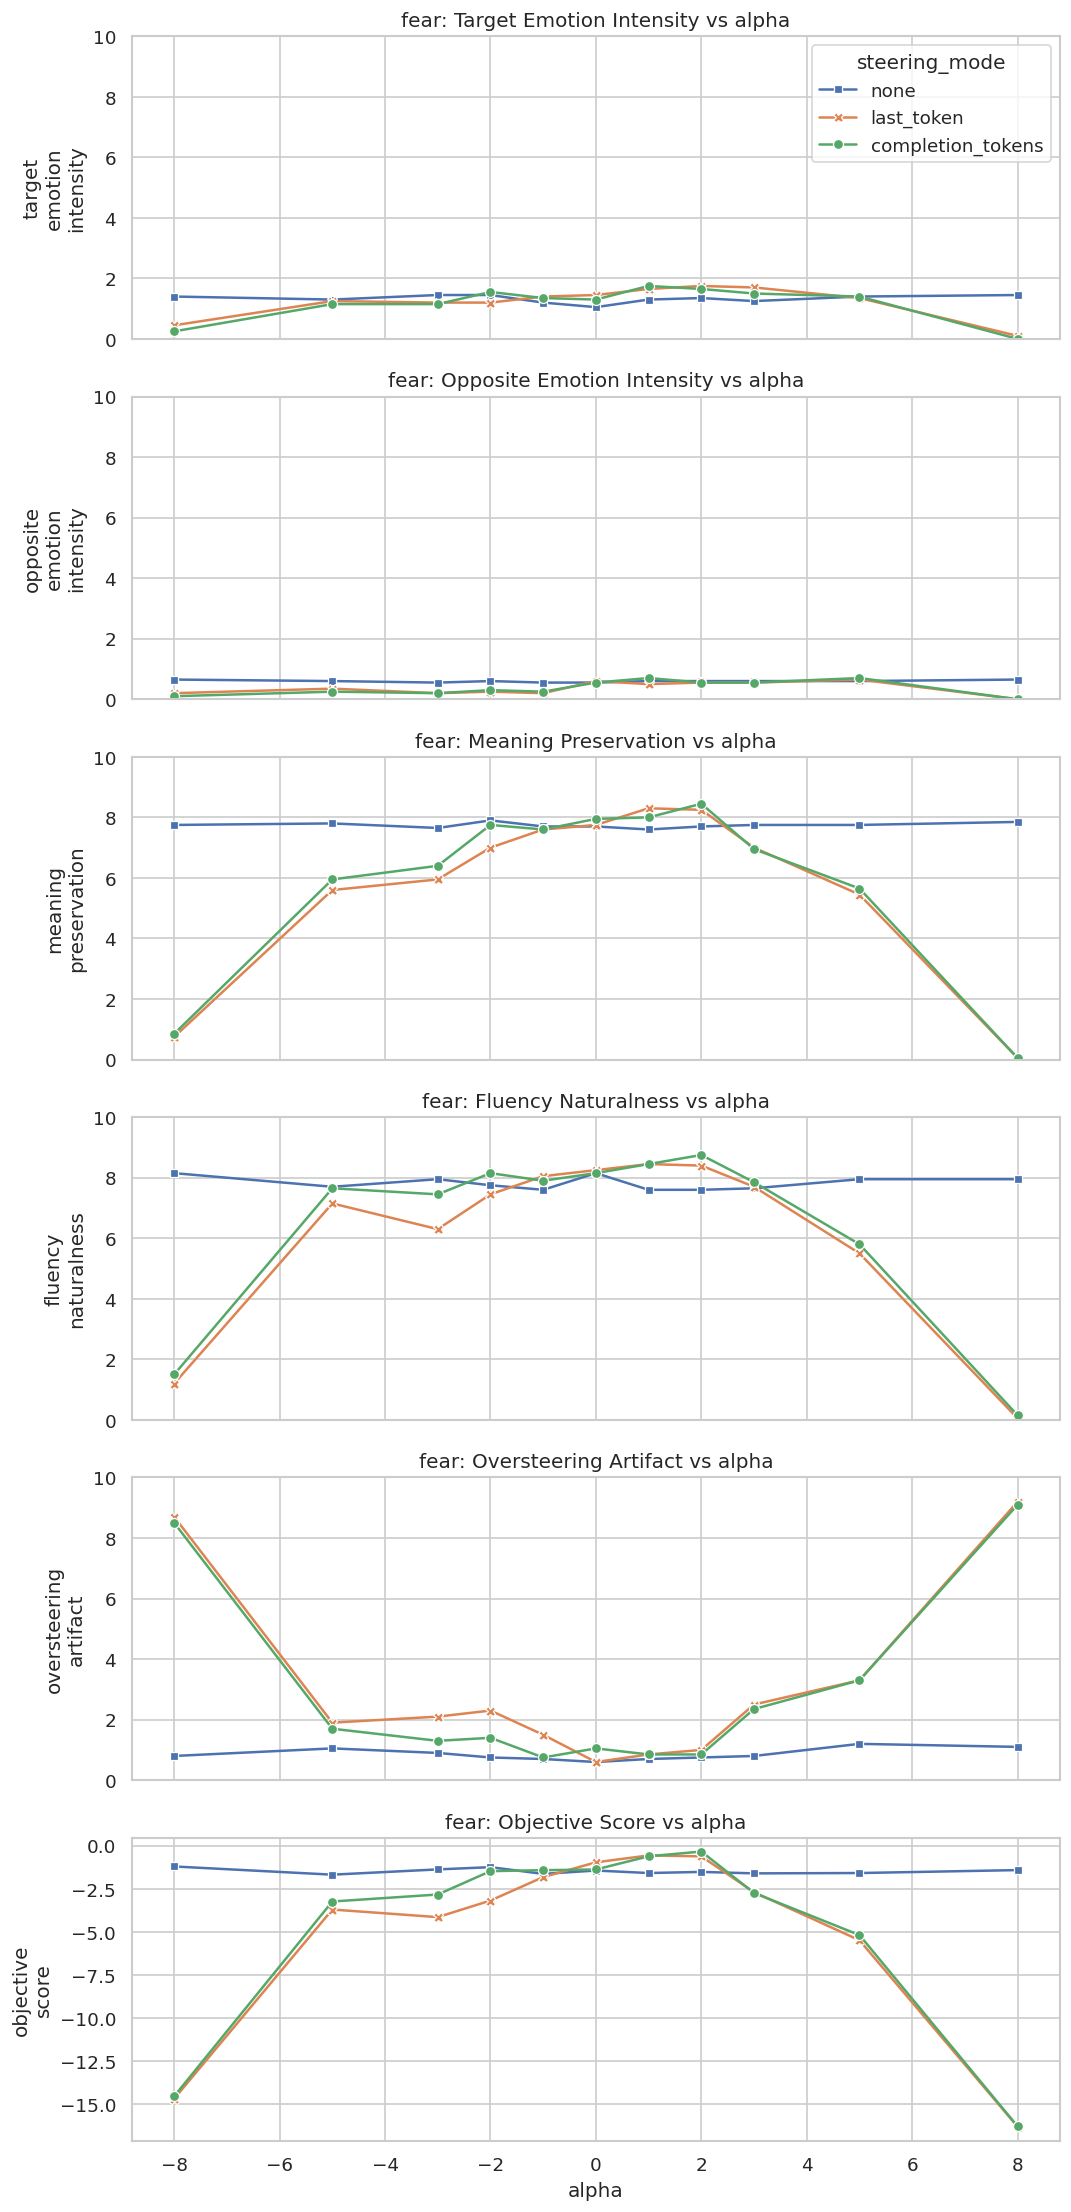

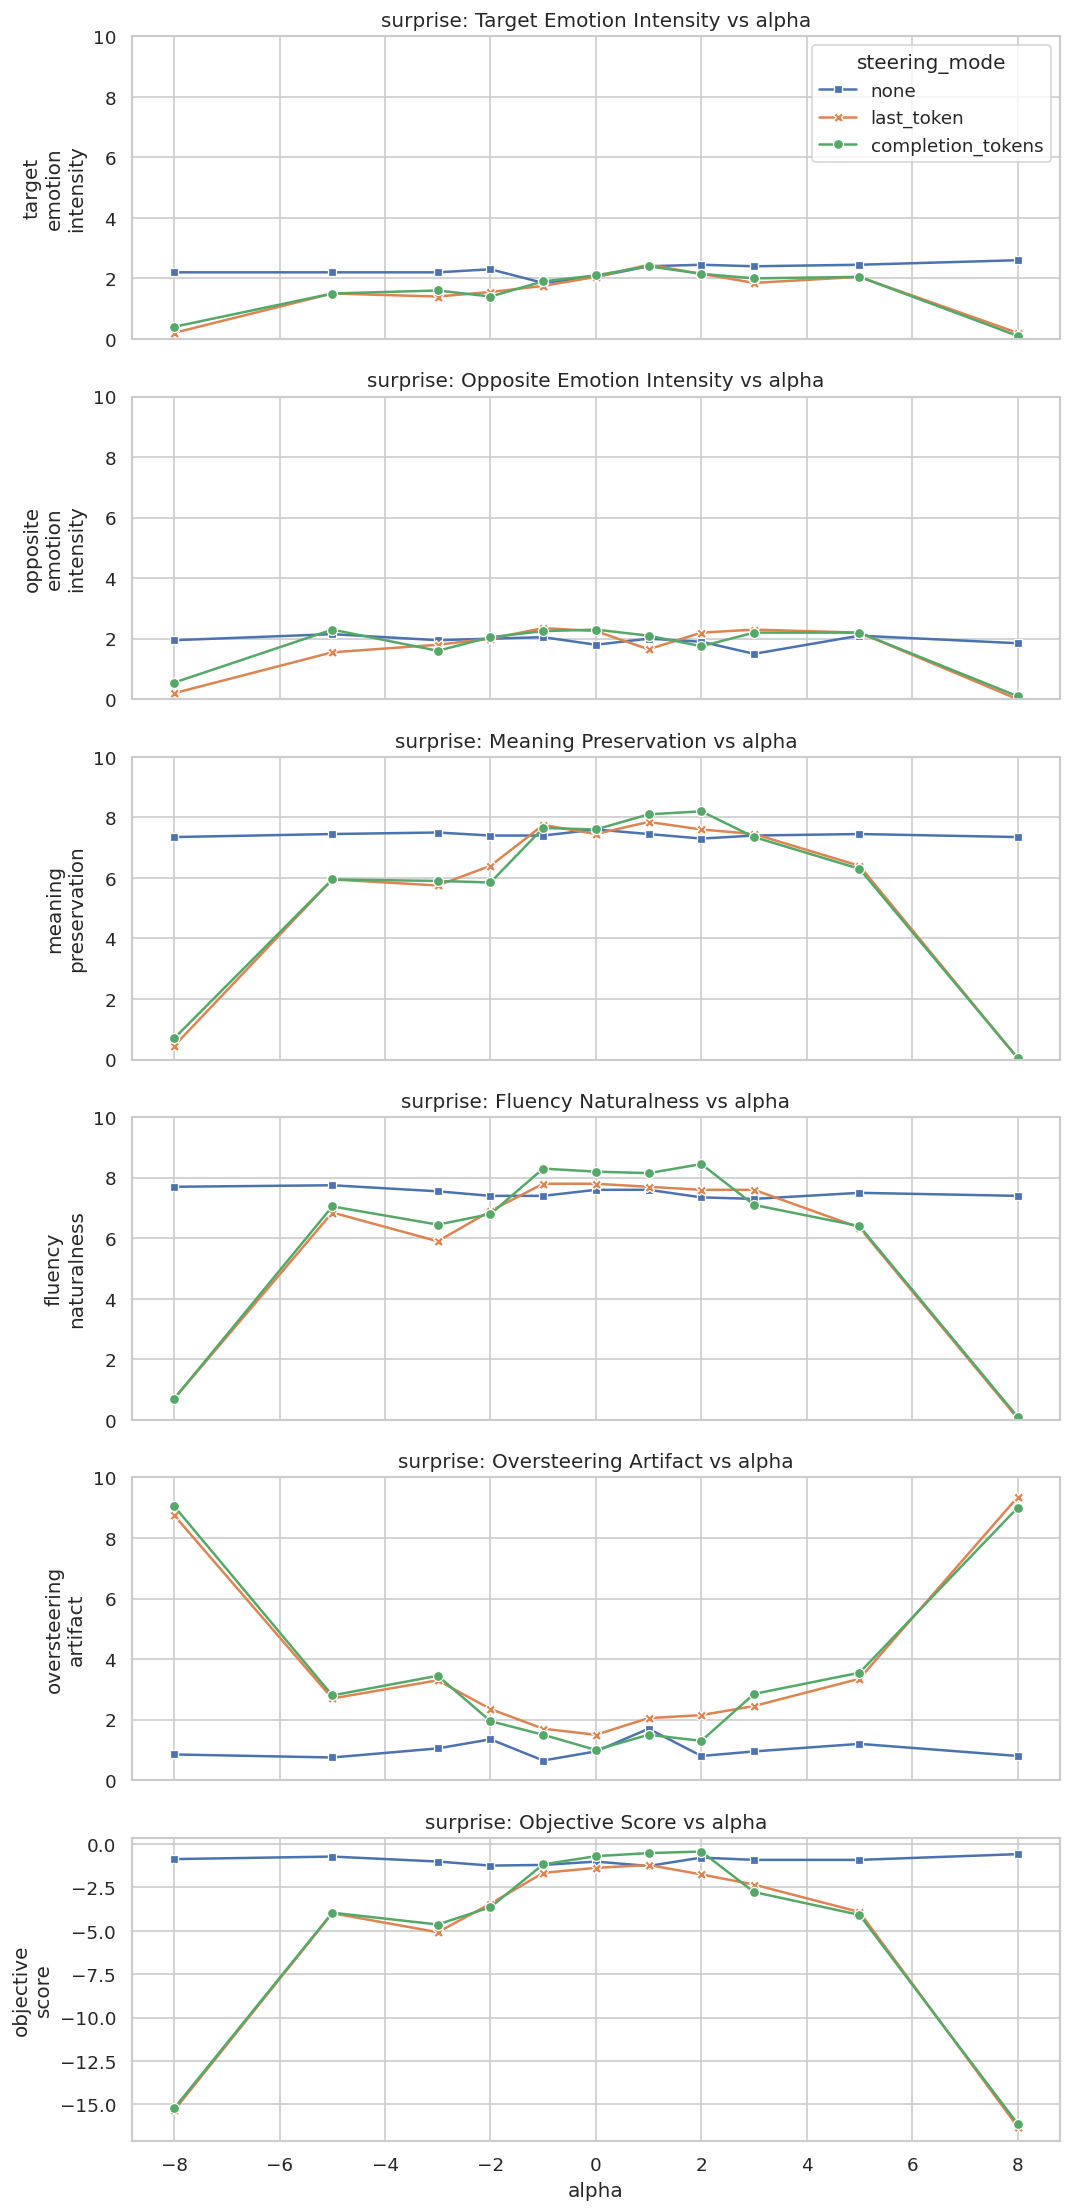

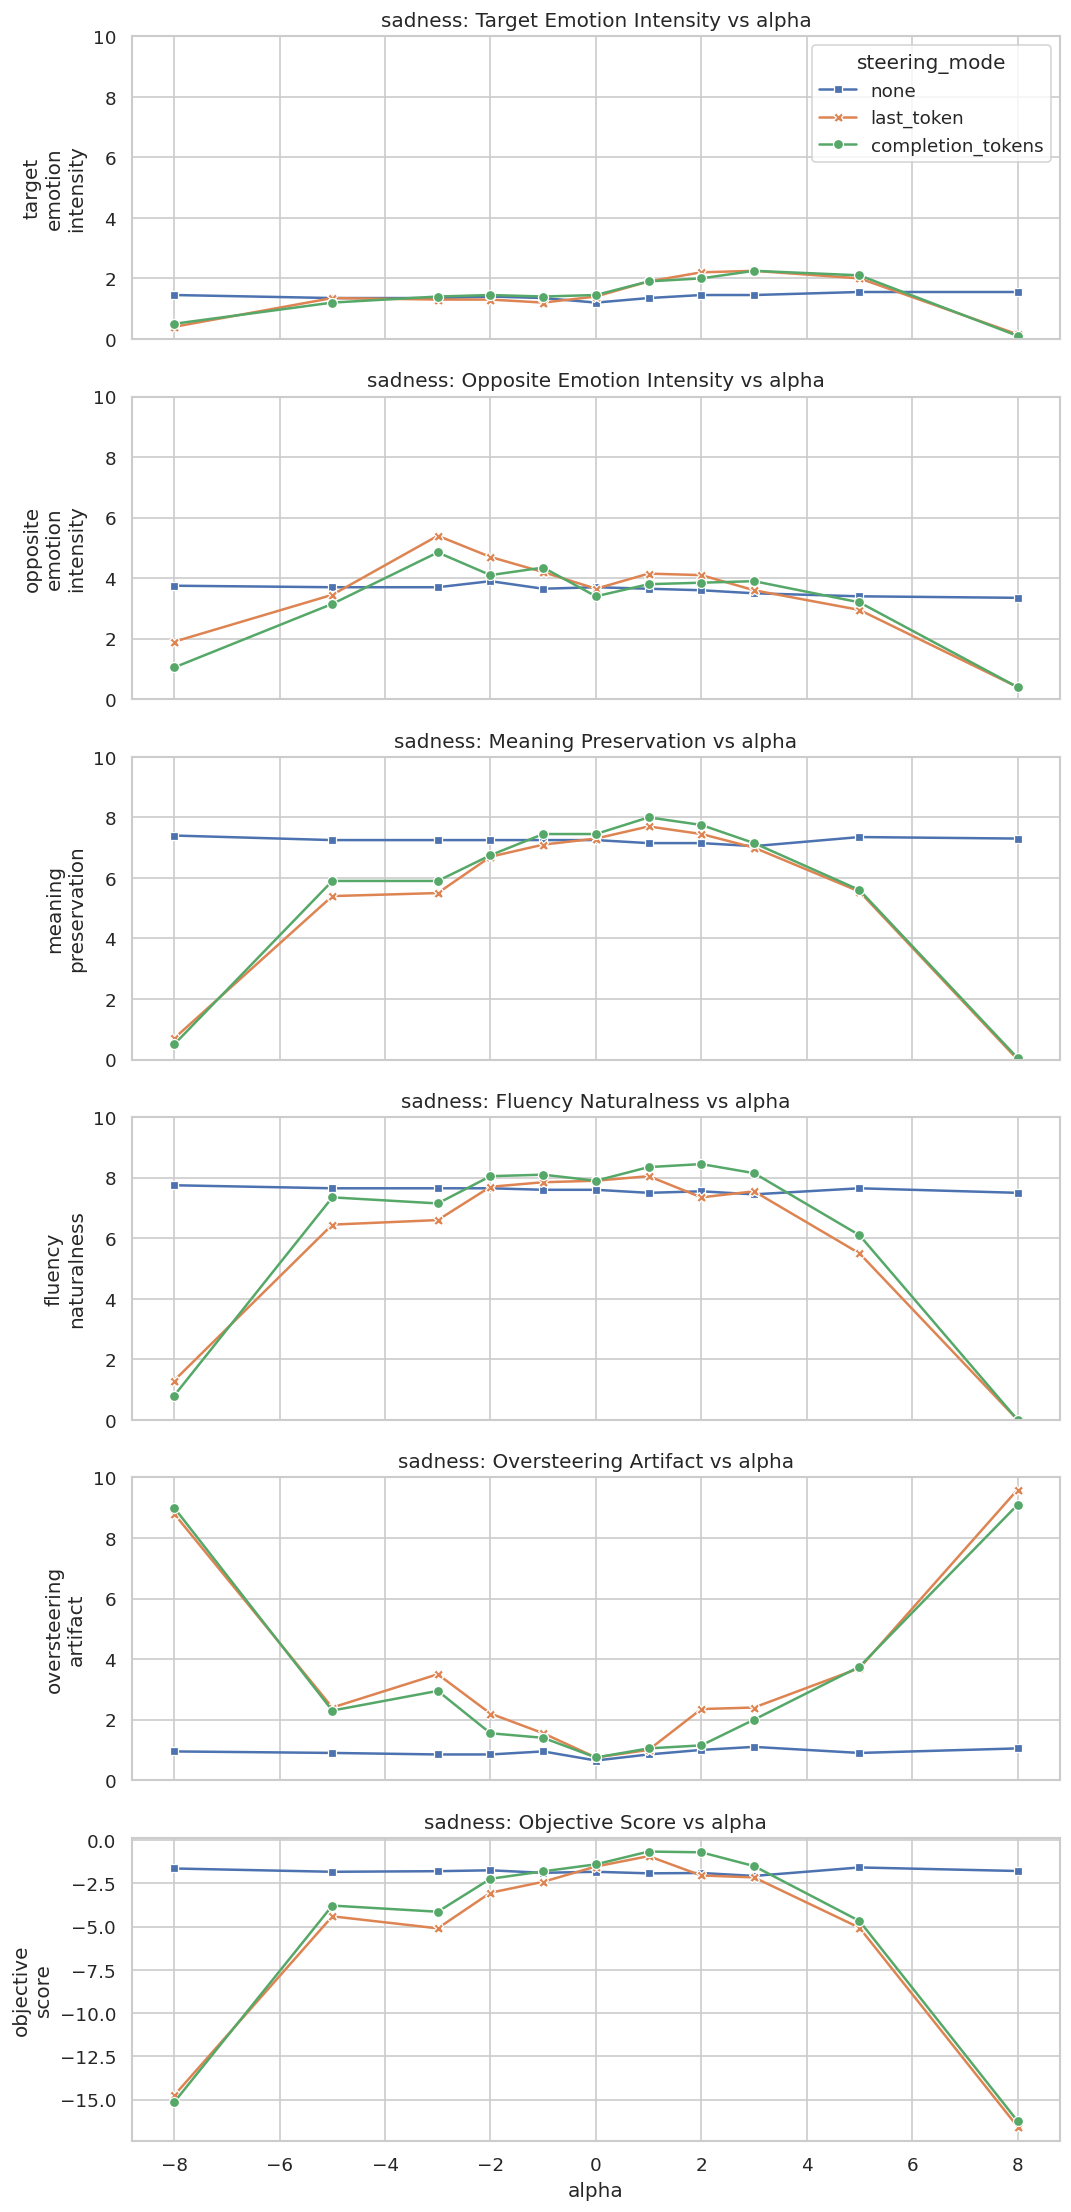

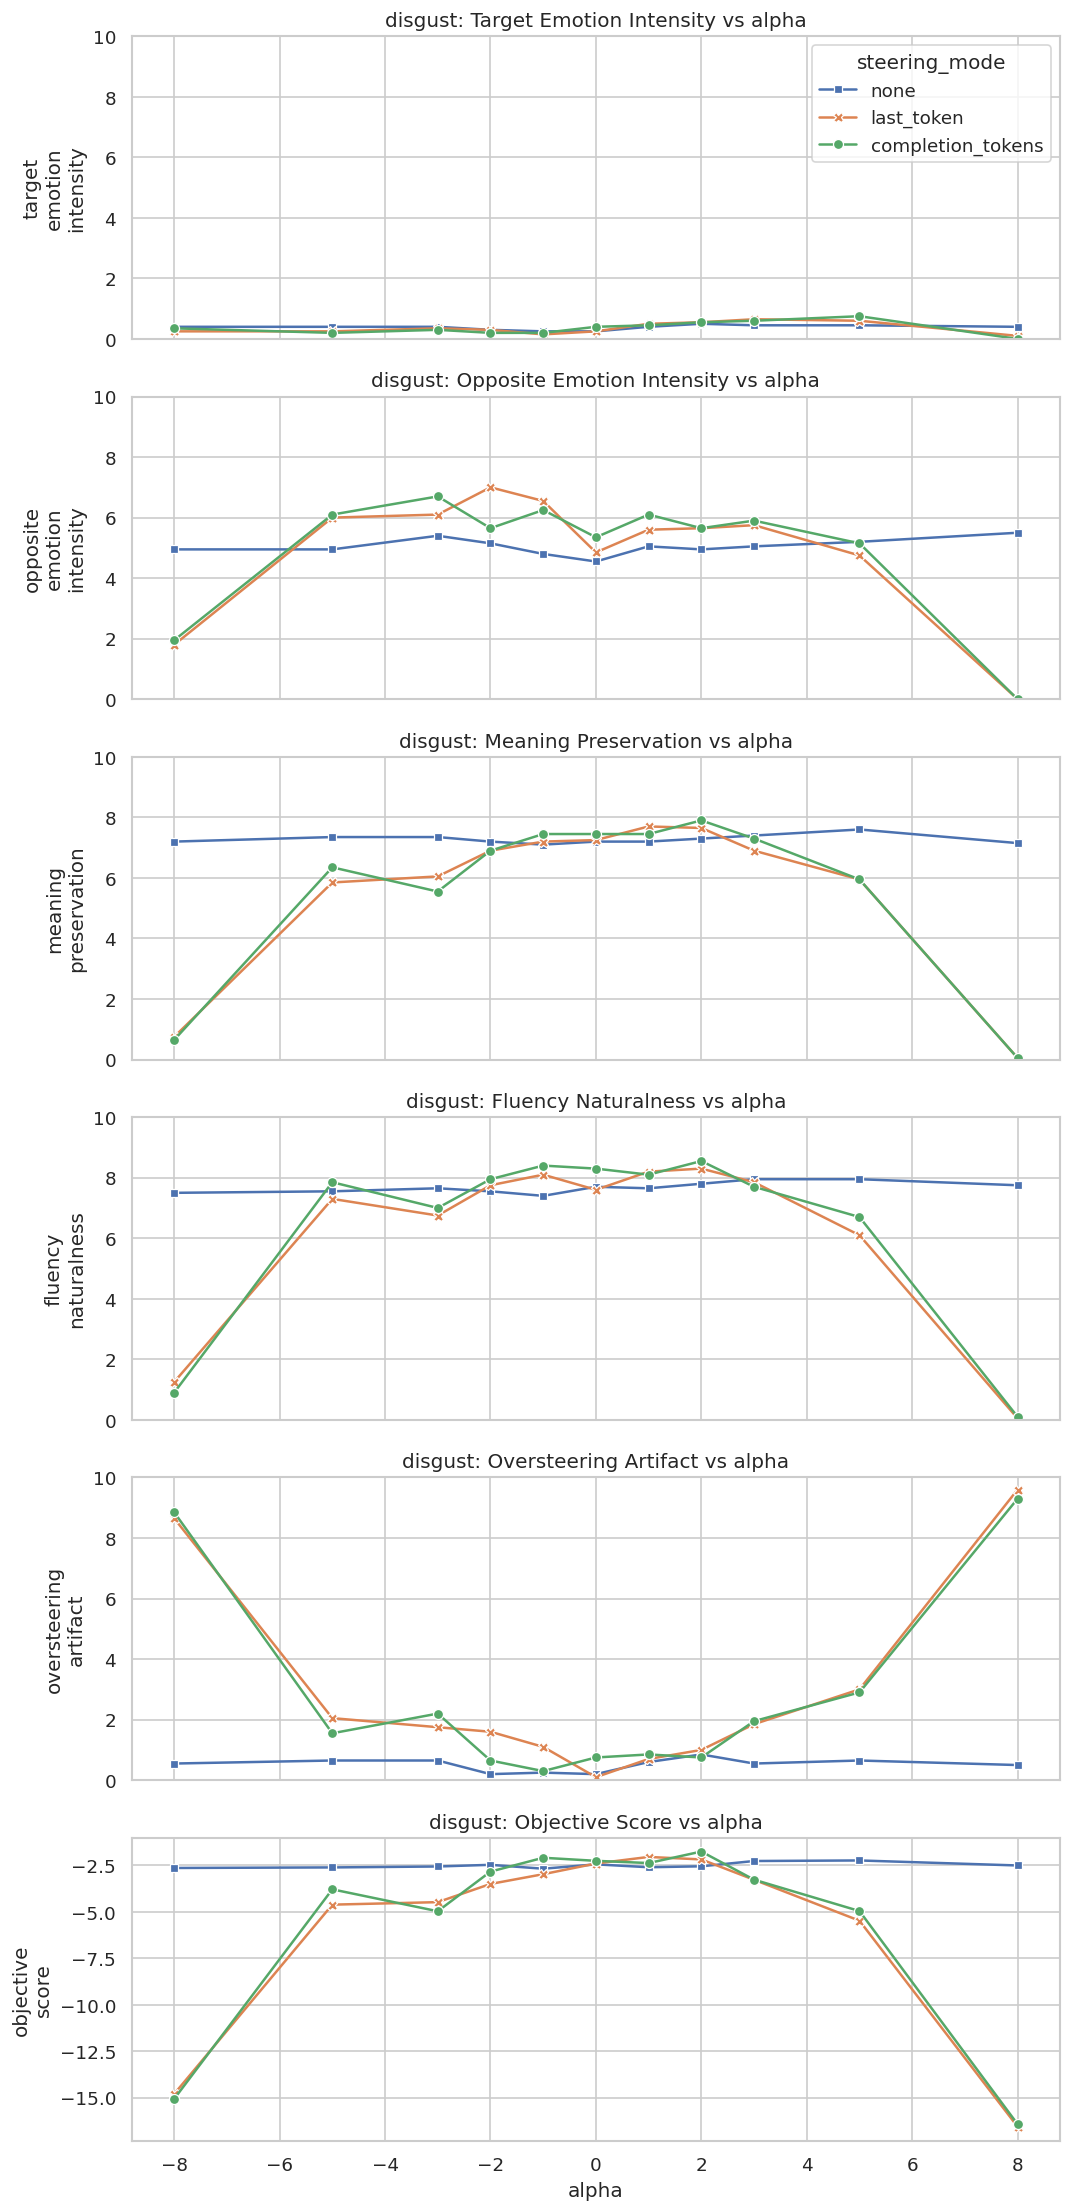

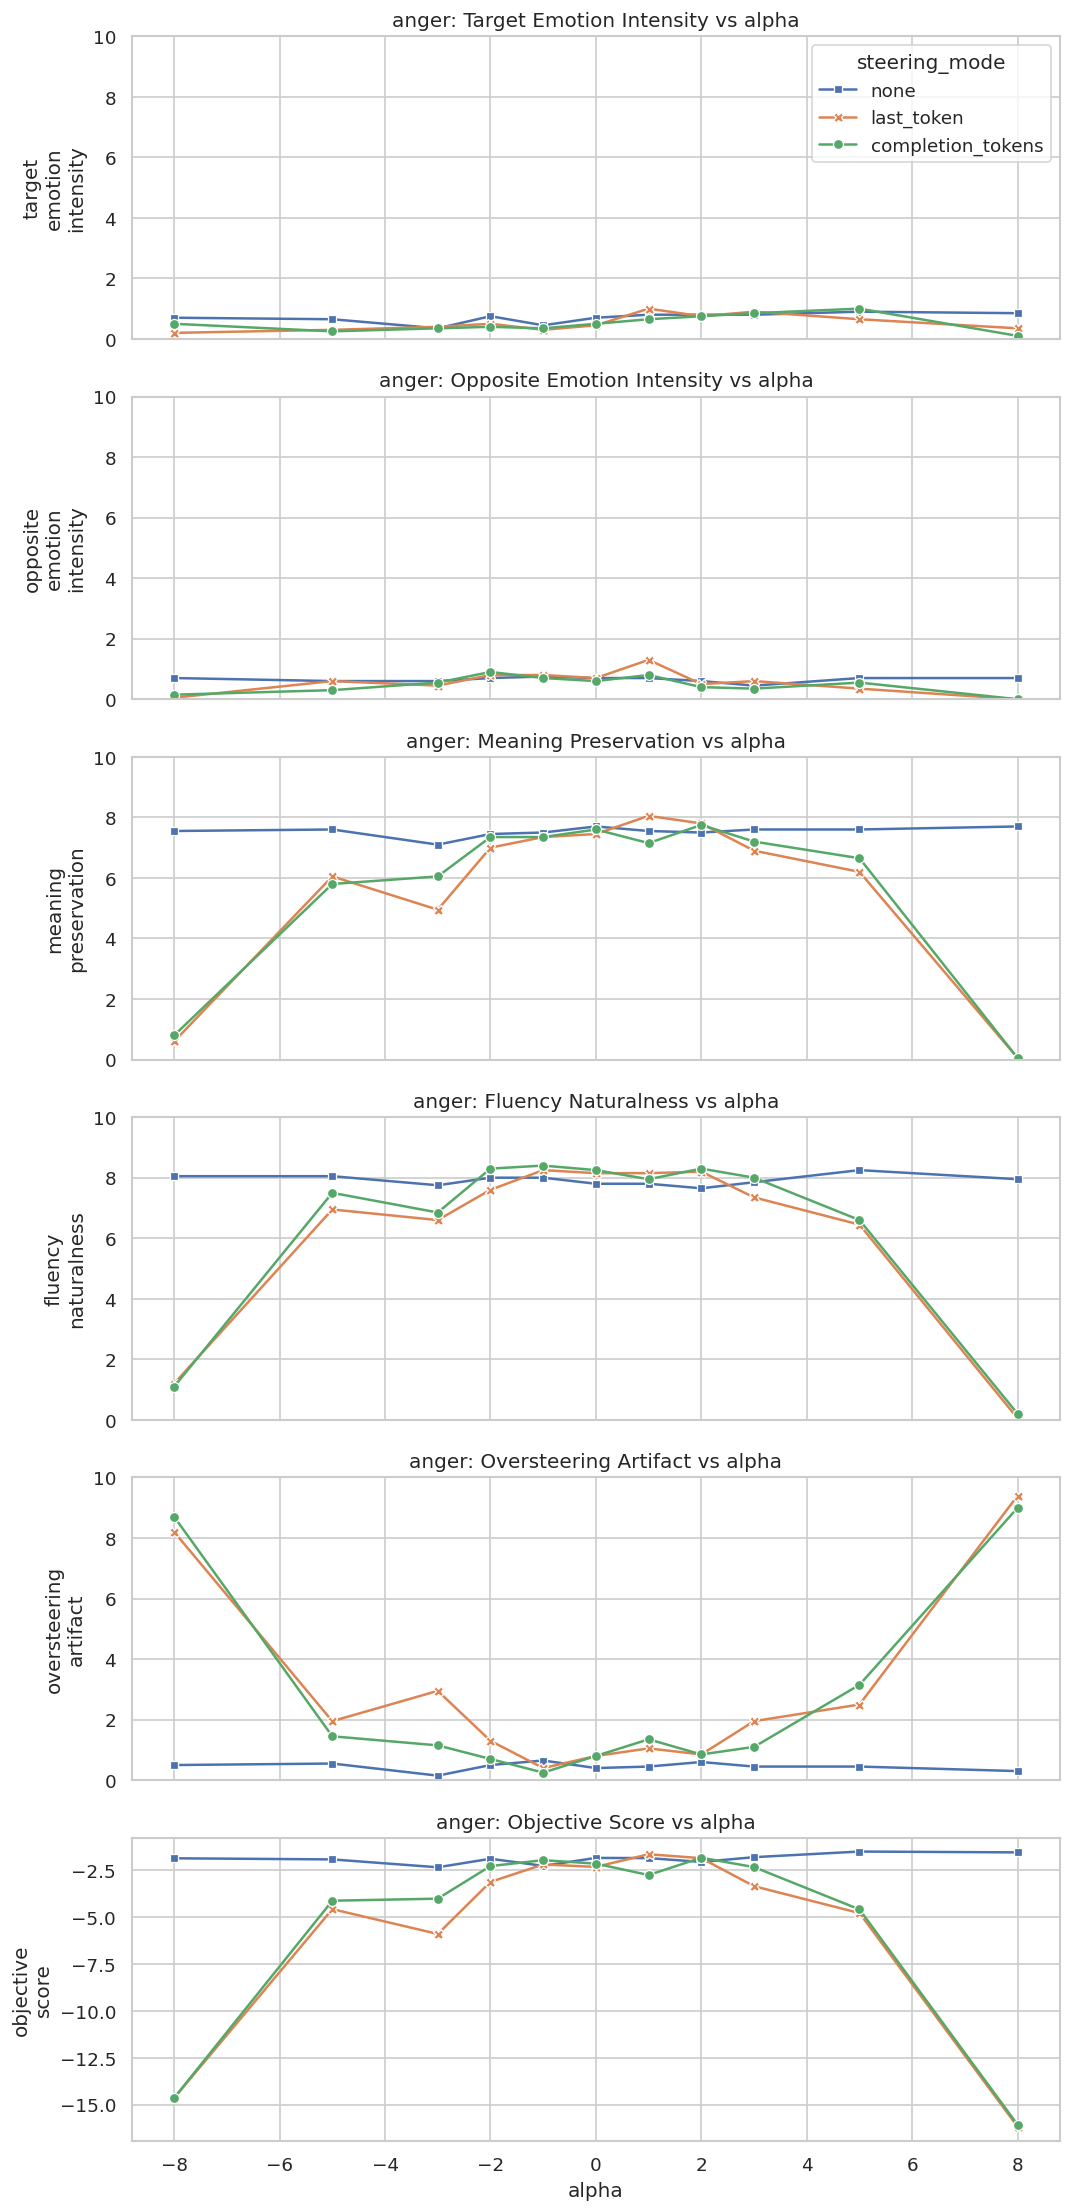

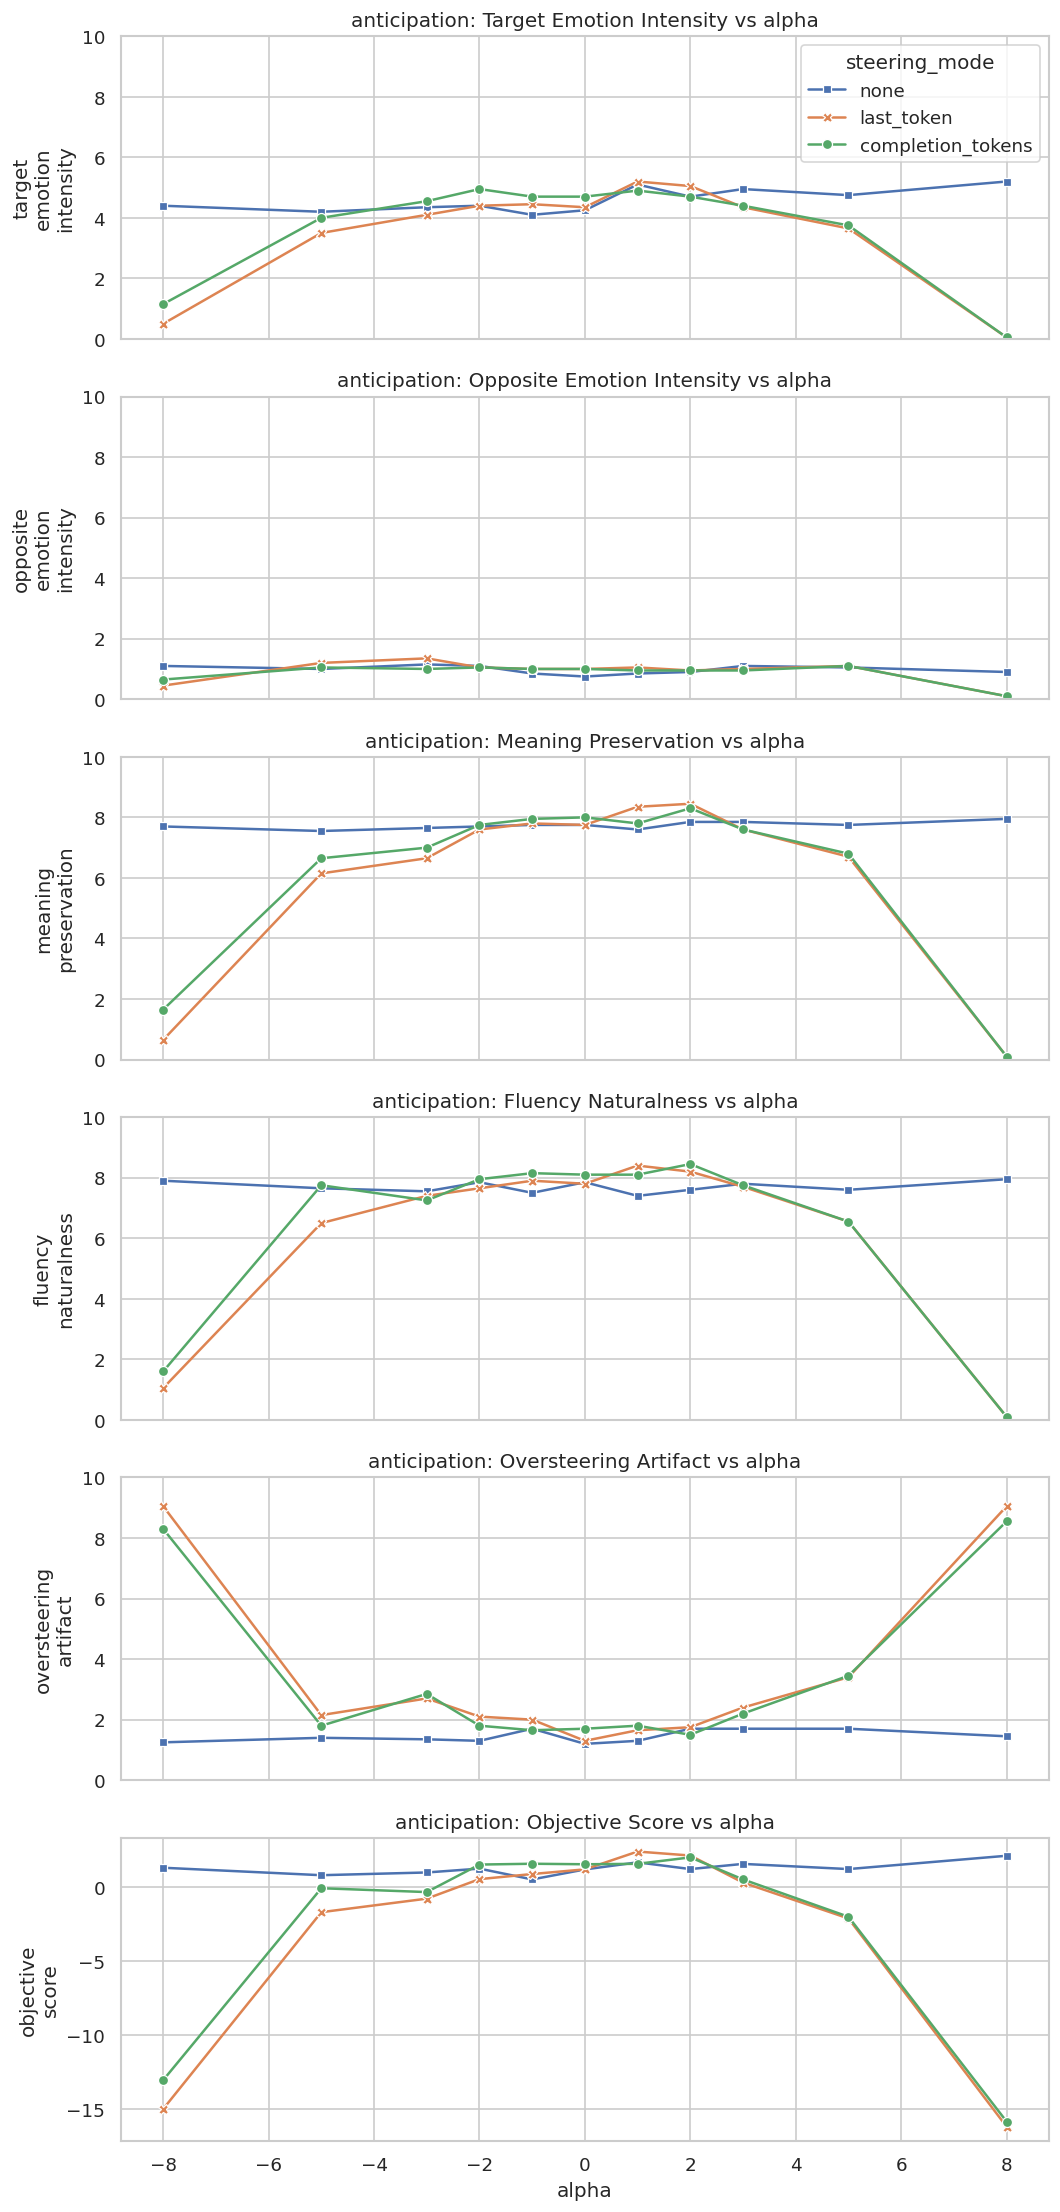

,target_emotion,steering_mode,alpha,target_emotion_intensity,opposite_emotion_intensity,meaning_preservation,fluency_naturalness,oversteering_artifact,objective_score,safe_alpha_range,safe_alpha_count
0,anger,completion_tokens,2.0,0.75,0.40,7.75,8.30,0.85,-1.820,NaN,NaN
1,anger,last_token,1.0,1.00,1.30,8.05,8.15,1.05,-1.635,1,1.0
2,anger,none,0.0,0.90,0.70,7.60,8.25,0.45,-1.490,NaN,NaN
3,anticipation,completion_tokens,2.0,4.70,0.95,8.30,8.45,1.50,2.025,"0, 2",2.0
4,anticipation,last_token,1.0,5.20,1.05,8.35,8.40,1.65,2.420,"1, 2",2.0
5,anticipation,none,0.0,5.20,0.90,7.95,7.95,1.45,2.135,NaN,NaN
6,disgust,completion_tokens,2.0,0.55,5.65,7.90,8.55,0.75,-1.750,NaN,NaN
7,disgust,last_token,1.0,0.50,5.60,7.70,8.20,0.70,-2.040,NaN,NaN
8,disgust,none,0.0,0.45,5.20,7.60,7.95,0.65,-2.230,NaN,NaN
9,fear,completion_tokens,2.0,1.65,0.55,8.45,8.75,0.85,-0.345,"1, 2",2.0


In [19]:
if judge_df is None or judge_df.empty:
    print('No parsed judge results available yet.')
else:
    analysis_df = judge_df.copy()
    if 'judge_error' in analysis_df.columns:
        analysis_df = analysis_df[analysis_df['judge_error'].isna()].copy()

    analysis_df['objective_score'] = (
        analysis_df['target_emotion_intensity']
        - 0.5 * (10 - analysis_df['meaning_preservation'])
        - 0.5 * (10 - analysis_df['fluency_naturalness'])
        - 0.7 * analysis_df['oversteering_artifact']
    )

    metric_cols = [
        'target_emotion_intensity',
        'opposite_emotion_intensity',
        'meaning_preservation',
        'fluency_naturalness',
        'oversteering_artifact',
        'objective_score',
    ]

    summary_df = (
        analysis_df
        .groupby(['target_emotion', 'steering_mode', 'alpha'], as_index=False)[metric_cols]
        .mean()
        .sort_values(['target_emotion', 'steering_mode', 'alpha'])
    )
    summary_df.to_csv(SUMMARY_CSV, index=False)

    best_alpha_df = (
        summary_df
        .sort_values(['target_emotion', 'steering_mode', 'objective_score'], ascending=[True, True, False])
        .groupby(['target_emotion', 'steering_mode'], as_index=False)
        .first()
    )
    best_alpha_df.loc[best_alpha_df['steering_mode'] == 'none', 'alpha'] = 0.0
    best_alpha_df.to_csv(BEST_ALPHA_CSV, index=False)

    safe_mask = (
        (summary_df['meaning_preservation'] >= SAFE_THRESHOLDS['meaning_preservation'])
        & (summary_df['fluency_naturalness'] >= SAFE_THRESHOLDS['fluency_naturalness'])
        & (summary_df['oversteering_artifact'] <= SAFE_THRESHOLDS['oversteering_artifact'])
    )
    safe_df = summary_df[safe_mask].copy()
    safe_range_df = (
        safe_df
        .groupby(['target_emotion', 'steering_mode'])['alpha']
        .apply(list)
        .reset_index(name='safe_alpha_values')
    )
    if safe_range_df.empty:
        safe_range_df = pd.DataFrame(columns=['target_emotion', 'steering_mode', 'safe_alpha_values', 'safe_alpha_range', 'safe_alpha_count'])
    else:
        safe_range_df['safe_alpha_range'] = safe_range_df.apply(
            lambda row: format_alpha_list(row['safe_alpha_values'], row['steering_mode']),
            axis=1,
        )
        safe_range_df['safe_alpha_count'] = safe_range_df['safe_alpha_values'].apply(len)
    safe_range_df.to_csv(SAFE_RANGE_CSV, index=False)

    plot_metrics = [
        'target_emotion_intensity',
        'opposite_emotion_intensity',
        'meaning_preservation',
        'fluency_naturalness',
        'oversteering_artifact',
        'objective_score',
    ]
    mode_order = ['none', 'last_token', 'completion_tokens']

    for emotion in EMOTION_ORDER:
        emotion_df = summary_df[summary_df['target_emotion'] == emotion].copy()
        if emotion_df.empty:
            continue

        fig, axes = plt.subplots(len(plot_metrics), 1, figsize=(9, 3.1 * len(plot_metrics)), sharex=True)
        for ax, metric in zip(axes, plot_metrics):
            sns.lineplot(
                data=emotion_df,
                x='alpha',
                y=metric,
                hue='steering_mode',
                hue_order=mode_order,
                style='steering_mode',
                markers=True,
                dashes=False,
                ax=ax,
            )
            title_metric = metric.replace('_', ' ').title()
            ylabel = metric.replace('_', '\n')
            ax.set_title(f'{emotion}: {title_metric} vs alpha')
            ax.set_ylabel(ylabel)
            if metric != 'objective_score':
                ax.set_ylim(0, 10)
            if metric != plot_metrics[0] and ax.get_legend() is not None:
                ax.get_legend().remove()
        axes[-1].set_xlabel('alpha')
        plt.tight_layout()
        plt.savefig(OUT_DIR / f'{emotion}_metric_vs_alpha.png', bbox_inches='tight')
        plt.show()

    report_df = best_alpha_df.merge(
        safe_range_df[['target_emotion', 'steering_mode', 'safe_alpha_range', 'safe_alpha_count']],
        on=['target_emotion', 'steering_mode'],
        how='left',
    )
    display(report_df)

In [20]:
if judge_df is None or judge_df.empty:
    print('No parsed judge results available yet.')
else:
    analysis_df = pd.read_csv(SUMMARY_CSV)

    zero_df = analysis_df[analysis_df['alpha'] == 0][[
        'target_emotion', 'steering_mode', 'target_emotion_intensity', 'opposite_emotion_intensity'
    ]].rename(columns={
        'target_emotion_intensity': 'target_at_zero',
        'opposite_emotion_intensity': 'opposite_at_zero',
    })

    negative_best_df = (
        analysis_df[analysis_df['alpha'] < 0]
        .sort_values(['target_emotion', 'steering_mode', 'objective_score'], ascending=[True, True, False])
        .groupby(['target_emotion', 'steering_mode'], as_index=False)
        .first()
        .merge(zero_df, on=['target_emotion', 'steering_mode'], how='left')
    )

    negative_best_df['delta_target_vs_zero'] = negative_best_df['target_emotion_intensity'] - negative_best_df['target_at_zero']
    negative_best_df['delta_opposite_vs_zero'] = negative_best_df['opposite_emotion_intensity'] - negative_best_df['opposite_at_zero']
    negative_best_df['negative_alpha_effect'] = negative_best_df.apply(interpret_negative_alpha, axis=1)
    negative_best_df.to_csv(NEGATIVE_ALPHA_CSV, index=False)

    safe_range_df = pd.read_csv(SAFE_RANGE_CSV) if SAFE_RANGE_CSV.exists() else pd.DataFrame()
    best_alpha_df = pd.read_csv(BEST_ALPHA_CSV) if BEST_ALPHA_CSV.exists() else pd.DataFrame()

    mode_best = best_alpha_df[best_alpha_df['steering_mode'].isin(['last_token', 'completion_tokens'])].copy()
    if not safe_range_df.empty:
        mode_best = mode_best.merge(
            safe_range_df[['target_emotion', 'steering_mode', 'safe_alpha_count']],
            on=['target_emotion', 'steering_mode'],
            how='left',
        )
    else:
        mode_best['safe_alpha_count'] = np.nan

    comparison_rows = []
    for emotion in EMOTION_ORDER:
        last_row = mode_best[(mode_best['target_emotion'] == emotion) & (mode_best['steering_mode'] == 'last_token')]
        comp_row = mode_best[(mode_best['target_emotion'] == emotion) & (mode_best['steering_mode'] == 'completion_tokens')]
        if last_row.empty or comp_row.empty:
            continue

        last_row = last_row.iloc[0]
        comp_row = comp_row.iloc[0]

        if comp_row['target_emotion_intensity'] > last_row['target_emotion_intensity'] + 0.5:
            stronger_mode = 'completion_tokens'
        elif last_row['target_emotion_intensity'] > comp_row['target_emotion_intensity'] + 0.5:
            stronger_mode = 'last_token'
        else:
            stronger_mode = 'similar'

        if comp_row['objective_score'] > last_row['objective_score'] + 0.5:
            cleaner_mode = 'completion_tokens'
        elif last_row['objective_score'] > comp_row['objective_score'] + 0.5:
            cleaner_mode = 'last_token'
        else:
            cleaner_mode = 'similar'

        last_safe = int(last_row['safe_alpha_count']) if pd.notna(last_row['safe_alpha_count']) else 0
        comp_safe = int(comp_row['safe_alpha_count']) if pd.notna(comp_row['safe_alpha_count']) else 0
        if comp_safe < last_safe:
            fragile_mode = 'completion_tokens'
        elif last_safe < comp_safe:
            fragile_mode = 'last_token'
        else:
            fragile_mode = 'similar'

        comparison_rows.append({
            'target_emotion': emotion,
            'best_alpha_last_token': last_row['alpha'],
            'best_alpha_completion_tokens': comp_row['alpha'],
            'objective_last_token': last_row['objective_score'],
            'objective_completion_tokens': comp_row['objective_score'],
            'stronger_mode': stronger_mode,
            'cleaner_mode': cleaner_mode,
            'more_fragile_mode': fragile_mode,
            'safe_count_last_token': last_safe,
            'safe_count_completion_tokens': comp_safe,
        })

    mode_comparison_df = pd.DataFrame(comparison_rows)
    mode_comparison_df.to_csv(MODE_COMPARISON_CSV, index=False)

    print('Best alpha per emotion and mode:')
    display(pd.read_csv(BEST_ALPHA_CSV))

print('Safe alpha ranges:')
if SAFE_RANGE_CSV.exists():
    display(pd.read_csv(SAFE_RANGE_CSV))

print('Negative alpha interpretation:')
display(negative_best_df)

print('Completion-token vs last-token comparison:')
display(mode_comparison_df)

overall_mode_summary = mode_comparison_df[['stronger_mode', 'cleaner_mode', 'more_fragile_mode']].apply(lambda col: col.value_counts()).fillna(0)
print('Overall mode comparison counts:')
display(overall_mode_summary)

Best alpha per emotion and mode:


,target_emotion,steering_mode,alpha,target_emotion_intensity,opposite_emotion_intensity,meaning_preservation,fluency_naturalness,oversteering_artifact,objective_score
0,anger,completion_tokens,2.0,0.75,0.40,7.75,8.30,0.85,-1.820
1,anger,last_token,1.0,1.00,1.30,8.05,8.15,1.05,-1.635
2,anger,none,0.0,0.90,0.70,7.60,8.25,0.45,-1.490
3,anticipation,completion_tokens,2.0,4.70,0.95,8.30,8.45,1.50,2.025
4,anticipation,last_token,1.0,5.20,1.05,8.35,8.40,1.65,2.420
5,anticipation,none,0.0,5.20,0.90,7.95,7.95,1.45,2.135
6,disgust,completion_tokens,2.0,0.55,5.65,7.90,8.55,0.75,-1.750
7,disgust,last_token,1.0,0.50,5.60,7.70,8.20,0.70,-2.040
8,disgust,none,0.0,0.45,5.20,7.60,7.95,0.65,-2.230
9,fear,completion_tokens,2.0,1.65,0.55,8.45,8.75,0.85,-0.345


Safe alpha ranges:


,target_emotion,steering_mode,safe_alpha_values,safe_alpha_range,safe_alpha_count
0,anger,last_token,[1.0],1,1
1,anticipation,completion_tokens,"[0.0, 2.0]","0, 2",2
2,anticipation,last_token,"[1.0, 2.0]","1, 2",2
3,fear,completion_tokens,"[1.0, 2.0]","1, 2",2
4,fear,last_token,"[1.0, 2.0]","1, 2",2
5,joy,completion_tokens,[2.0],2,1
6,joy,last_token,[2.0],2,1
7,sadness,completion_tokens,[1.0],1,1
8,surprise,completion_tokens,"[1.0, 2.0]","1, 2",2
9,trust,completion_tokens,[2.0],2,1


Negative alpha interpretation:


,target_emotion,steering_mode,alpha,target_emotion_intensity,opposite_emotion_intensity,meaning_preservation,fluency_naturalness,oversteering_artifact,objective_score,target_at_zero,opposite_at_zero,delta_target_vs_zero,delta_opposite_vs_zero,negative_alpha_effect
0,anger,completion_tokens,-1.0,0.35,0.70,7.35,8.40,0.25,-1.950,0.50,0.60,-0.15,0.10,negative alpha is weak or mixed
1,anger,last_token,-1.0,0.30,0.80,7.35,8.25,0.40,-2.180,0.45,0.70,-0.15,0.10,negative alpha is weak or mixed
2,anger,none,-8.0,0.70,0.70,7.55,8.05,0.50,-1.850,0.70,0.70,0.00,0.00,negative alpha is weak or mixed
3,anticipation,completion_tokens,-1.0,4.70,1.00,7.95,8.15,1.65,1.595,4.70,1.00,0.00,0.00,negative alpha is weak or mixed
4,anticipation,last_token,-1.0,4.45,1.00,7.80,7.90,2.00,0.900,4.35,1.00,0.10,0.00,negative alpha is weak or mixed
5,anticipation,none,-8.0,4.40,1.10,7.70,7.90,1.25,1.325,4.25,0.75,0.15,0.35,negative alpha is weak or mixed
6,disgust,completion_tokens,-1.0,0.20,6.25,7.45,8.40,0.30,-2.085,0.40,5.35,-0.20,0.90,negative alpha is weak or mixed
7,disgust,last_token,-1.0,0.15,6.55,7.20,8.10,1.10,-2.970,0.25,4.85,-0.10,1.70,negative alpha increases opposite emotion
8,disgust,none,-2.0,0.30,5.15,7.20,7.55,0.20,-2.465,0.25,4.55,0.05,0.60,negative alpha is weak or mixed
9,fear,completion_tokens,-1.0,1.35,0.25,7.60,7.90,0.75,-1.425,1.30,0.55,0.05,-0.30,negative alpha is weak or mixed


Completion-token vs last-token comparison:


,target_emotion,best_alpha_last_token,best_alpha_completion_tokens,objective_last_token,objective_completion_tokens,stronger_mode,cleaner_mode,more_fragile_mode,safe_count_last_token,safe_count_completion_tokens
0,joy,2.0,2.0,1.565,1.925,similar,similar,similar,1,1
1,trust,2.0,2.0,2.795,3.550,similar,completion_tokens,completion_tokens,2,1
2,fear,1.0,2.0,-0.570,-0.345,similar,similar,similar,2,2
3,surprise,1.0,2.0,-1.210,-0.435,similar,completion_tokens,last_token,0,2
4,sadness,1.0,1.0,-0.925,-0.660,similar,similar,last_token,0,1
5,disgust,1.0,2.0,-2.040,-1.750,similar,similar,similar,0,0
6,anger,1.0,2.0,-1.635,-1.820,similar,similar,completion_tokens,1,0
7,anticipation,1.0,2.0,2.420,2.025,similar,similar,similar,2,2


Overall mode comparison counts:


,stronger_mode,cleaner_mode,more_fragile_mode
completion_tokens,0.0,2.0,2
last_token,0.0,0.0,2
similar,8.0,6.0,4


In [25]:
# %% [markdown]
# ## Manual inspection: all alpha-sweep rewrites
#
# LLM judge scores are useful for rough screening, but threshold decisions should be
# manually inspected. This cell displays all cached generation results in dark-mode
# HTML cards, grouped by emotion, source text, steering mode, and alpha.

# %%
from pathlib import Path
import pandas as pd
import numpy as np
import html
from IPython.display import display, HTML

# Reuse OUT_DIR if already defined
try:
    OUT_DIR
except NameError:
    REPO_ROOT = Path("../..").resolve()
    OUT_DIR = REPO_ROOT / "analysis" / "caa" / "position_mode_steering"

GENERATIONS_CSV = OUT_DIR / "position_mode_generations.csv"
JUDGE_PARSED_CSV = OUT_DIR / "position_mode_judge_parsed.csv"

print("OUT_DIR:", OUT_DIR)
print("GENERATIONS_CSV:", GENERATIONS_CSV.exists(), GENERATIONS_CSV)
print("JUDGE_PARSED_CSV:", JUDGE_PARSED_CSV.exists(), JUDGE_PARSED_CSV)

if not GENERATIONS_CSV.exists():
    raise FileNotFoundError(
        f"Generation cache not found: {GENERATIONS_CSV}\n"
        "Run the alpha sweep generation cell first."
    )

gen_df = pd.read_csv(GENERATIONS_CSV)
gen_df["alpha"] = pd.to_numeric(gen_df["alpha"], errors="coerce")

# Optionally merge judge scores if available, but do not rely on them.
if JUDGE_PARSED_CSV.exists():
    judge_df = pd.read_csv(JUDGE_PARSED_CSV)
    judge_df["alpha"] = pd.to_numeric(judge_df["alpha"], errors="coerce")

    metric_cols = [
        "target_emotion_intensity",
        "opposite_emotion_intensity",
        "meaning_preservation",
        "fluency_naturalness",
        "oversteering_artifact",
        "objective_score",
        "brief_rationale",
    ]
    metric_cols = [c for c in metric_cols if c in judge_df.columns]

    merge_keys = [
        k for k in [
            "source_id",
            "target_emotion",
            "opposite_emotion",
            "alpha",
            "steering_mode",
            "layer",
        ]
        if k in gen_df.columns and k in judge_df.columns
    ]

    if merge_keys and metric_cols:
        gen_df = gen_df.merge(
            judge_df[merge_keys + metric_cols].drop_duplicates(subset=merge_keys),
            on=merge_keys,
            how="left",
        )

required_cols = {"target_emotion", "steering_mode", "alpha", "base_text", "generated_text"}
missing = required_cols - set(gen_df.columns)
if missing:
    raise ValueError(f"Missing required columns in generation cache: {missing}")

# Display config
EMOTION_ORDER = [
    "joy", "trust", "fear", "surprise",
    "sadness", "disgust", "anger", "anticipation",
]
MODE_ORDER = ["none", "last_token", "completion_tokens"]

# Put none/baseline first, then negative to positive alphas.
def alpha_sort_key(a):
    if pd.isna(a):
        return 999
    return float(a)

gen_df["emotion_order"] = gen_df["target_emotion"].apply(
    lambda x: EMOTION_ORDER.index(x) if x in EMOTION_ORDER else 999
)
gen_df["mode_order"] = gen_df["steering_mode"].apply(
    lambda x: MODE_ORDER.index(x) if x in MODE_ORDER else 999
)

source_cols = [c for c in ["source_id", "source_split", "intensity_level"] if c in gen_df.columns]

# ---------------------------------------------------------------------
# Controls: edit these to reduce/increase output size
# ---------------------------------------------------------------------

# Show all emotions by default. Set to e.g. ["joy", "sadness"] if output is too large.
EMOTIONS_TO_SHOW = ["sadness"]

# Show all modes. You can set ["last_token", "completion_tokens"] to hide baseline.
MODES_TO_SHOW = ["last_token", "completion_tokens"]

# Show all alphas. You can set e.g. [-3, -2, -1, 0, 1, 2, 3] to narrow.
ALPHAS_TO_SHOW = sorted(gen_df["alpha"].dropna().unique().tolist())

# Show all cached source texts by default.
# Set to an int like 5 to show only first 5 source texts per emotion.
MAX_SOURCES_PER_EMOTION = None

# If True, show judge scores if merged. If False, hide them completely.
SHOW_JUDGE_SCORES = True

# If True, show judge rationale if available. Usually noisy; default False.
SHOW_JUDGE_RATIONALE = False

# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------
def esc(x):
    if pd.isna(x):
        return ""
    return html.escape(str(x))

def fmt_float(x, ndigits=2):
    if pd.isna(x):
        return "NA"
    try:
        return f"{float(x):.{ndigits}f}"
    except Exception:
        return esc(x)

def format_meta(row):
    bits = []
    for c in source_cols:
        bits.append(f"{c}={esc(row.get(c, ''))}")
    return " | ".join(bits)

def mode_badge(mode):
    if mode == "none":
        return '<span class="badge badge-none">none</span>'
    if mode == "last_token":
        return '<span class="badge badge-last">last_token</span>'
    if mode == "completion_tokens":
        return '<span class="badge badge-completion">completion_tokens</span>'
    return f'<span class="badge">{esc(mode)}</span>'

def alpha_badge(alpha):
    try:
        a = float(alpha)
    except Exception:
        return f'<span class="alpha-badge">{esc(alpha)}</span>'

    if a < 0:
        cls = "alpha-neg"
    elif a > 0:
        cls = "alpha-pos"
    else:
        cls = "alpha-zero"

    return f'<span class="alpha-badge {cls}">α={a:g}</span>'

def score_line(row):
    metric_cols = [
        ("target", "target_emotion_intensity"),
        ("opposite", "opposite_emotion_intensity"),
        ("meaning", "meaning_preservation"),
        ("fluency", "fluency_naturalness"),
        ("oversteer", "oversteering_artifact"),
        ("objective", "objective_score"),
    ]
    present = [(label, col) for label, col in metric_cols if col in row.index]
    if not present:
        return ""

    bits = []
    for label, col in present:
        bits.append(f"{label}={fmt_float(row[col])}")
    return '<div class="score-line">' + " | ".join(bits) + "</div>"

# ---------------------------------------------------------------------
# Dark-mode renderer
# ---------------------------------------------------------------------
def render_all_alpha_sweep(df):
    df = df[
        df["target_emotion"].isin(EMOTIONS_TO_SHOW)
        & df["steering_mode"].isin(MODES_TO_SHOW)
        & df["alpha"].isin(ALPHAS_TO_SHOW)
    ].copy()

    df = df.sort_values(
        ["emotion_order", "target_emotion", "source_id", "mode_order", "steering_mode", "alpha"],
        kind="stable",
    )

    css = """
    <style>
    :root {
        color-scheme: dark;
    }

    .manual-sweep-wrap {
        font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif;
        line-height: 1.5;
        color: #e8e8e8;
        background: #0f1117;
        padding: 18px;
        border-radius: 14px;
    }

    .manual-sweep-wrap * {
        box-sizing: border-box;
    }

    .top-note {
        background: #171b24;
        border: 1px solid #2a3140;
        color: #cbd5e1;
        padding: 14px 16px;
        border-radius: 10px;
        margin-bottom: 22px;
    }

    .emotion-section {
        margin: 34px 0 46px 0;
        padding-top: 18px;
        border-top: 3px solid #64748b;
    }

    .emotion-title {
        font-size: 28px;
        font-weight: 850;
        letter-spacing: 0.03em;
        margin: 0 0 16px 0;
        color: #f8fafc;
    }

    .source-card {
        background: #151922;
        border: 1px solid #2d3443;
        border-radius: 14px;
        margin: 18px 0 28px 0;
        overflow: hidden;
        box-shadow: 0 6px 18px rgba(0,0,0,0.28);
    }

    .source-header {
        background: #1f2531;
        border-bottom: 1px solid #2d3443;
        padding: 14px 16px;
    }

    .source-title {
        font-size: 16px;
        font-weight: 800;
        color: #e2e8f0;
        margin-bottom: 6px;
    }

    .source-meta {
        font-family: ui-monospace, SFMono-Regular, Menlo, Monaco, Consolas, monospace;
        font-size: 12px;
        color: #94a3b8;
        margin-bottom: 10px;
        overflow-wrap: anywhere;
    }

    .base-text {
        white-space: pre-wrap;
        overflow-wrap: anywhere;
        word-break: break-word;
        background: #0f172a;
        border: 1px solid #263041;
        color: #e5e7eb;
        padding: 12px;
        border-radius: 9px;
    }

    .mode-block {
        padding: 14px 16px 6px 16px;
        border-top: 1px solid #252b38;
    }

    .mode-heading {
        font-size: 17px;
        font-weight: 800;
        color: #f1f5f9;
        margin: 4px 0 12px 0;
    }

    .rewrite-card {
        background: #10141d;
        border: 1px solid #2c3342;
        border-radius: 12px;
        padding: 13px 14px;
        margin: 10px 0 14px 0;
    }

    .rewrite-card.alpha-negative {
        border-left: 6px solid #fb7185;
    }

    .rewrite-card.alpha-positive {
        border-left: 6px solid #38bdf8;
    }

    .rewrite-card.alpha-zero {
        border-left: 6px solid #94a3b8;
    }

    .rewrite-header {
        display: flex;
        align-items: center;
        gap: 8px;
        flex-wrap: wrap;
        margin-bottom: 8px;
    }

    .badge {
        display: inline-block;
        font-family: ui-monospace, SFMono-Regular, Menlo, Monaco, Consolas, monospace;
        font-size: 12px;
        font-weight: 700;
        padding: 3px 7px;
        border-radius: 999px;
        background: #334155;
        color: #e2e8f0;
        border: 1px solid #475569;
    }

    .badge-none {
        background: #374151;
        border-color: #4b5563;
    }

    .badge-last {
        background: #1e3a8a;
        border-color: #2563eb;
        color: #dbeafe;
    }

    .badge-completion {
        background: #064e3b;
        border-color: #059669;
        color: #d1fae5;
    }

    .alpha-badge {
        display: inline-block;
        font-family: ui-monospace, SFMono-Regular, Menlo, Monaco, Consolas, monospace;
        font-size: 13px;
        font-weight: 850;
        padding: 3px 8px;
        border-radius: 8px;
        background: #1f2937;
        color: #f8fafc;
        border: 1px solid #475569;
    }

    .alpha-neg {
        color: #fecdd3;
        border-color: #fb7185;
        background: #3f1d2a;
    }

    .alpha-pos {
        color: #bae6fd;
        border-color: #38bdf8;
        background: #082f49;
    }

    .alpha-zero {
        color: #e5e7eb;
        border-color: #94a3b8;
        background: #374151;
    }

    .score-line {
        font-family: ui-monospace, SFMono-Regular, Menlo, Monaco, Consolas, monospace;
        font-size: 12px;
        color: #cbd5e1;
        background: #161b26;
        border: 1px solid #2a3140;
        padding: 8px 10px;
        border-radius: 8px;
        margin: 8px 0;
        white-space: normal;
        overflow-wrap: anywhere;
    }

    .generated-text {
        white-space: pre-wrap;
        overflow-wrap: anywhere;
        word-break: break-word;
        color: #f8fafc;
        background: #0b1020;
        border: 1px solid #20283a;
        padding: 12px;
        border-radius: 9px;
        font-size: 15px;
    }

    .rationale {
        margin-top: 9px;
        white-space: pre-wrap;
        overflow-wrap: anywhere;
        word-break: break-word;
        color: #fde68a;
        background: #251a07;
        border: 1px solid #5b4210;
        padding: 10px;
        border-radius: 8px;
        font-size: 13px;
    }

    .small-label {
        font-weight: 800;
        color: #cbd5e1;
        margin: 8px 0 4px 0;
    }

    .counts {
        font-family: ui-monospace, SFMono-Regular, Menlo, Monaco, Consolas, monospace;
        font-size: 12px;
        color: #a7f3d0;
    }
    </style>
    """

    parts = [
        css,
        '<div class="manual-sweep-wrap">',
        f"""
        <div class="top-note">
          <b>Manual alpha-sweep inspection</b><br>
          Showing cached rewrites from <code>position_mode_generations.csv</code>.
          Judge scores are shown only as weak hints if available; decide thresholds by reading the text.
          <div class="counts">
            rows={len(df)} |
            emotions={len(df["target_emotion"].dropna().unique())} |
            sources={len(df["source_id"].dropna().unique()) if "source_id" in df.columns else "NA"} |
            modes={", ".join(map(str, df["steering_mode"].dropna().unique()))}
          </div>
        </div>
        """
    ]

    for emotion in EMOTIONS_TO_SHOW:
        emo_df = df[df["target_emotion"] == emotion].copy()
        if emo_df.empty:
            continue

        parts.append(f"""
        <section class="emotion-section">
          <div class="emotion-title">{esc(emotion).upper()}</div>
        """)

        source_ids = emo_df["source_id"].dropna().unique().tolist() if "source_id" in emo_df.columns else [None]
        if MAX_SOURCES_PER_EMOTION is not None:
            source_ids = source_ids[:MAX_SOURCES_PER_EMOTION]

        for source_id in source_ids:
            if source_id is None:
                src_df = emo_df.copy()
            else:
                src_df = emo_df[emo_df["source_id"] == source_id].copy()

            if src_df.empty:
                continue

            first = src_df.iloc[0]

            parts.append(f"""
            <div class="source-card">
              <div class="source-header">
                <div class="source-title">Source: <code>{esc(source_id)}</code></div>
                <div class="source-meta">{format_meta(first)}</div>
                <div class="small-label">Base text</div>
                <div class="base-text">{esc(first.get("base_text", ""))}</div>
              </div>
            """)

            for mode in MODES_TO_SHOW:
                mode_df = src_df[src_df["steering_mode"] == mode].copy()
                if mode_df.empty:
                    continue

                mode_df = mode_df.sort_values("alpha")

                parts.append(f"""
                <div class="mode-block">
                  <div class="mode-heading">{mode_badge(mode)}</div>
                """)

                for _, row in mode_df.iterrows():
                    alpha = row.get("alpha", np.nan)
                    try:
                        a = float(alpha)
                    except Exception:
                        a = 0.0

                    if a < 0:
                        alpha_cls = "alpha-negative"
                    elif a > 0:
                        alpha_cls = "alpha-positive"
                    else:
                        alpha_cls = "alpha-zero"

                    parts.append(f"""
                    <div class="rewrite-card {alpha_cls}">
                      <div class="rewrite-header">
                        {mode_badge(mode)}
                        {alpha_badge(alpha)}
                      </div>
                    """)

                    if SHOW_JUDGE_SCORES:
                        parts.append(score_line(row))

                    parts.append(f"""
                      <div class="generated-text">{esc(row.get("generated_text", ""))}</div>
                    """)

                    if SHOW_JUDGE_RATIONALE and "brief_rationale" in row.index and pd.notna(row.get("brief_rationale")):
                        parts.append(f"""
                        <div class="rationale">
                          <b>Judge rationale:</b><br>{esc(row.get("brief_rationale", ""))}
                        </div>
                        """)

                    parts.append("</div>")

                parts.append("</div>")

            parts.append("</div>")

        parts.append("</section>")

    parts.append("</div>")
    display(HTML("\n".join(parts)))

render_all_alpha_sweep(gen_df)

OUT_DIR: /home/maplesugano/proj/EmotionEngine_v2/analysis/caa/position_mode_steering
GENERATIONS_CSV: True /home/maplesugano/proj/EmotionEngine_v2/analysis/caa/position_mode_steering/position_mode_generations.csv
JUDGE_PARSED_CSV: True /home/maplesugano/proj/EmotionEngine_v2/analysis/caa/position_mode_steering/position_mode_judge_parsed.csv
